<a href="https://colab.research.google.com/github/raymonxian-collab/afl-disposal-modelling/blob/main/afl_disposal_final_ver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AFL Disposal Model — Cleaned & Reordered

This notebook has been restructured so **Run All** works top-to-bottom:
- Cells reordered into dependency order (scrape → clean → merge → model → evaluate)
- Duplicate/overwriting cells removed (kept the most complete version of each step)
- Fixed the `venue` KeyError by using the venue-scraping version of the game-stats loop

**Before running:** re-upload `complete player positions .xlsx` to the Colab file browser each session (Colab wipes local files on restart). Consider mounting Google Drive instead so it persists.


## 1. Scrape season totals (baseline season averages)

Setup working
Libraries ready ✓
200
Page size: 510462 characters


/tmp/ipykernel_393/3705387921.py:14: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


Number of tables found: 19
    0                                                  1
0 NaN  Abbreviations key #=Jumper GM=Games played KI=...
Table 0: (1, 2) columns: [0, 1]

Table 1: (37, 28) columns: [('Adelaide [Players Game by Game][Team Game by Game]', '#'), ('Adelaide [Players Game by Game][Team Game by Game]', 'Player'), ('Adelaide [Players Game by Game][Team Game by Game]', 'GM'), ('Adelaide [Players Game by Game][Team Game by Game]', 'KI'), ('Adelaide [Players Game by Game][Team Game by Game]', 'MK')]

Table 2: (36, 28) columns: [('Brisbane Lions [Players Game by Game][Team Game by Game]', '#'), ('Brisbane Lions [Players Game by Game][Team Game by Game]', 'Player'), ('Brisbane Lions [Players Game by Game][Team Game by Game]', 'GM'), ('Brisbane Lions [Players Game by Game][Team Game by Game]', 'KI'), ('Brisbane Lions [Players Game by Game][Team Game by Game]', 'MK')]

Table 3: (40, 28) columns: [('Carlton [Players Game by Game][Team Game by Game]', '#'), ('Carlton [Players Game 

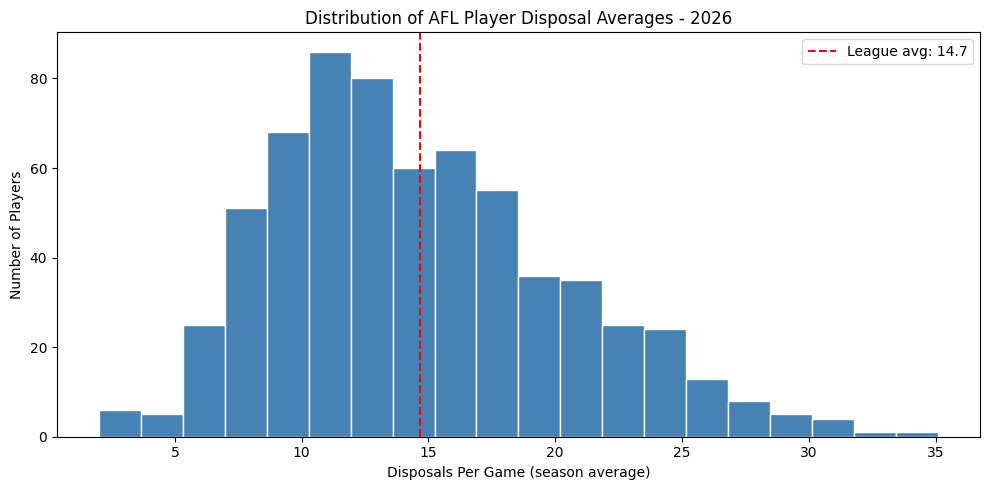

League average disposals per game: 14.7
Highest: Daicos, Nick - 35.1
Lowest: King, Max - 2.0
652 players exported
                     player                    team position
0              Daicos, Nick             Collingwood         
1             Smith, Bailey                 Geelong         
2            Sheezel, Harry         North Melbourne         
3           Oliver, Clayton  Greater Western Sydney         
4  Wanganeen-Milera, Nasiah                St Kilda         


In [1]:
import pandas as pd
print("Setup working")

import requests
import pandas as pd
print("Libraries ready ✓")

url = "https://afltables.com/afl/stats/2026.html"
response = requests.get(url, headers={"User-Agent": "afl-disposal-model-learning-project"})
print(response.status_code)
print(f"Page size: {len(response.text)} characters")

# pandas can read HTML tables directly from a page
tables = pd.read_html(response.text)
print(f"Number of tables found: {len(tables)}")
print(tables[0].head())  # preview the first table

for i, table in enumerate(tables):
    print(f"Table {i}: {table.shape} columns: {list(table.columns[:5])}")
    print()

all_players = []

for i in range(1, 19):
    table = tables[i].copy()

    # get team name from the top level of the multi-index column
    team_name = tables[i].columns[0][0].replace(" [Players Game by Game][Team Game by Game]", "")

    # flatten columns to just the stat abbreviation (bottom level)
    table.columns = [col[1] for col in tables[i].columns]

    # add team column
    table['team'] = team_name

    all_players.append(table)

# stack them on top of each other
df = pd.concat(all_players, ignore_index=True)

print(df.shape)
print(df.columns.tolist())
print(df.head())

# keep only the columns we care about
df_clean = df[['Player', 'team', 'GM', 'KI', 'HB', 'DI']].copy()

# rename for clarity
df_clean.columns = ['player', 'team', 'games', 'kicks', 'handballs', 'disposals']

# convert to numbers (some might be strings)
for col in ['games', 'kicks', 'handballs', 'disposals']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# drop rows with no data (substitute/rookie listed players who played 0 games)
df_clean = df_clean.dropna()
df_clean = df_clean[df_clean['games'] > 0]

# calculate per game averages
df_clean['disposals_per_game'] = (df_clean['disposals'] / df_clean['games']).round(1)
df_clean['kicks_per_game'] = (df_clean['kicks'] / df_clean['games']).round(1)
df_clean['handballs_per_game'] = (df_clean['handballs'] / df_clean['games']).round(1)

# sort by disposals per game
df_clean = df_clean.sort_values('disposals_per_game', ascending=False).reset_index(drop=True)

print(df_clean.shape)
print(df_clean.head(10))

# the baseline prediction for each player is simply their season average
df_clean['baseline_prediction'] = df_clean['disposals_per_game']

# to evaluate it properly we need to simulate:
# "if we predicted their season average, how wrong were we per game?"
# we can approximate this using each player's kicks vs handballs variability
# but first - let's just look at the distribution of averages

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df_clean['disposals_per_game'], bins=20, color='steelblue', edgecolor='white')
plt.xlabel('Disposals Per Game (season average)')
plt.ylabel('Number of Players')
plt.title('Distribution of AFL Player Disposal Averages - 2026')
plt.axvline(df_clean['disposals_per_game'].mean(), color='red', linestyle='--', label=f"League avg: {df_clean['disposals_per_game'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"League average disposals per game: {df_clean['disposals_per_game'].mean():.1f}")
print(f"Highest: {df_clean.iloc[0]['player']} - {df_clean.iloc[0]['disposals_per_game']}")
print(f"Lowest: {df_clean.iloc[-1]['player']} - {df_clean.iloc[-1]['disposals_per_game']}")

player_list = df_clean[['player', 'team']].copy()
player_list['position'] = ''  # empty column for you to fill in

player_list.to_csv('players_to_classify.csv', index=False)
print(f"{len(player_list)} players exported")
print(player_list.head())


## 2. Scrape game-by-game data

In [2]:
from io import StringIO
from bs4 import BeautifulSoup
import time

# get the 2026 season index page
season_url = "https://afltables.com/afl/seas/2026.html"
response = requests.get(season_url, headers={"User-Agent": "afl-disposal-model-learning-project"})
print(response.status_code)

soup = BeautifulSoup(response.text, 'html.parser')

game_links = []
for a in soup.find_all('a', href=True):
    href = a['href']
    # fix relative paths
    if 'stats/games/2026/' in href:
        # handle both absolute and relative hrefs
        if href.startswith('http'):
            full_url = href
        elif href.startswith('/'):
            full_url = 'https://afltables.com' + href
        else:
            # relative like ../../stats/games/2026/...
            full_url = 'https://afltables.com/afl/' + href.lstrip('./')

        # clean up any double slashes
        full_url = full_url.replace('afltables.com//', 'afltables.com/')

        if full_url not in game_links:
            game_links.append(full_url)

print(f"Found {len(game_links)} game URLs")
print(game_links[:5])

200
Found 171 game URLs
['https://afltables.com/afl/stats/games/2026/031620260305.html', 'https://afltables.com/afl/stats/games/2026/092020260306.html', 'https://afltables.com/afl/stats/games/2026/102120260307.html', 'https://afltables.com/afl/stats/games/2026/071920260307.html', 'https://afltables.com/afl/stats/games/2026/041520260308.html']


In [3]:
from bs4 import BeautifulSoup
import time

all_game_stats = []

for i, url in enumerate(game_links):
    try:
        response = requests.get(url, headers={"User-Agent": "afl-disposal-model-learning-project"})
        soup = BeautifulSoup(response.text, 'html.parser')

        game_id = url.split('/')[-1].replace('.html', '')

        # extract venue - find first link containing 'venues' in href
        venue = 'Unknown'
        for a in soup.find_all('a', href=lambda h: h and 'venues' in str(h)):
            venue = a.get_text(strip=True)
            break

        tables = pd.read_html(StringIO(response.text))

        team_names = []
        for tag in soup.find_all(['h2','h3','caption','th']):
            text = tag.get_text(strip=True)
            if 'Match Statistics' in text:
                team = text.replace('Match Statistics','').strip()
                if team:
                    team_names.append(team)

        if len(team_names) < 2:
            title = soup.find('title')
            if title:
                title_text = title.text.split('-')[0].strip()
                if ' v ' in title_text:
                    parts = title_text.split(' v ')
                    team_names = [parts[0].strip(), parts[1].strip()]

        team_idx = 0
        for table in tables:
            if isinstance(table.columns, pd.MultiIndex):
                table.columns = [col[-1] for col in table.columns]
            if 'DI' not in table.columns or 'Player' not in table.columns:
                continue

            team = team_names[team_idx] if team_idx < len(team_names) else 'Unknown'
            opponent = team_names[1 - team_idx] if len(team_names) == 2 else 'Unknown'

            for _, row in table.iterrows():
                player = str(row.get('Player', '')).strip()
                if not player or player == 'nan' or player == 'Player':
                    continue
                all_game_stats.append({
                    'player': player,
                    'team': team,
                    'opponent': opponent,
                    'venue': venue,
                    'game_id': game_id,
                    'disposals': pd.to_numeric(row.get('DI'), errors='coerce'),
                    'kicks': pd.to_numeric(row.get('KI'), errors='coerce'),
                    'handballs': pd.to_numeric(row.get('HB'), errors='coerce'),
                })
            team_idx += 1

        if (i + 1) % 10 == 0:
            print(f"Scraped {i + 1}/{len(game_links)} games...")

        time.sleep(0.5)

    except Exception as e:
        print(f"Error on {url}: {e}")
        continue

df_games = pd.DataFrame(all_game_stats)
df_games['team'] = df_games['team'].str.replace(r'\[.*?\]', '', regex=True).str.strip()
df_games['opponent'] = df_games['opponent'].str.replace(r'\[.*?\]', '', regex=True).str.strip()

print(f"\nDone! Shape: {df_games.shape}")
print(df_games[['player','team','opponent','venue','disposals']].head(5))
print(f"\nUnique venues: {sorted(df_games['venue'].unique())}")

Scraped 10/171 games...
Scraped 20/171 games...
Scraped 30/171 games...
Scraped 40/171 games...
Scraped 50/171 games...
Scraped 60/171 games...
Scraped 70/171 games...
Scraped 80/171 games...
Scraped 90/171 games...
Scraped 100/171 games...
Scraped 110/171 games...
Scraped 120/171 games...
Scraped 130/171 games...
Scraped 140/171 games...
Scraped 150/171 games...
Scraped 160/171 games...
Scraped 170/171 games...

Done! Shape: (8854, 8)
            player    team opponent   venue  disposals
0    Amartey, Joel  Sydney  Carlton  S.C.G.        7.0
1      Bice, Riley  Sydney  Carlton  S.C.G.       16.0
2     Blakey, Nick  Sydney  Carlton  S.C.G.       21.0
3  Curnow, Charlie  Sydney  Carlton  S.C.G.       10.0
4   Grundy, Brodie  Sydney  Carlton  S.C.G.       16.0

Unique venues: ['Adelaide Oval', 'Barossa Park', 'Bellerive Oval', 'Carrara', 'Docklands', 'Gabba', 'Hands Oval', 'Kardinia Park', 'M.C.G.', 'Manuka Oval', 'Marrara Oval', 'Norwood Oval', 'Perth Stadium', 'S.C.G.', 'Sydney Showgr

In [4]:
from bs4 import BeautifulSoup

season_url = "https://afltables.com/afl/seas/2026.html"
response = requests.get(season_url, headers={"User-Agent": "afl-disposal-model-learning-project"})
soup = BeautifulSoup(response.text, 'html.parser')

round_map = {}
current_round = None

for tag in soup.find_all(True):
    text = tag.get_text(strip=True)
    if tag.name in ['td', 'th'] and text.startswith('Round') and len(text) < 15:
        current_round = text.replace('Round ', '').strip()
    if tag.name == 'a':
        href = tag.get('href', '')
        if 'stats/games/2026/' in href:
            game_id = href.split('/')[-1].replace('.html', '')
            if current_round and game_id not in round_map:
                round_map[game_id] = current_round

# assign to df_games
df_games['round'] = df_games['game_id'].map(round_map)
df_games['round'] = df_games['round'].fillna('1').astype(int)

print(df_games.groupby('round')['game_id'].nunique().sort_index())
print(f"\nTotal games: {df_games['game_id'].nunique()}")

round
1     5
2     9
3     7
4     7
5     8
6     9
7     9
8     9
9     9
10    9
11    9
12    9
13    7
14    8
15    7
16    7
17    7
18    9
19    9
20    9
21    9
Name: game_id, dtype: int64

Total games: 171


## 3. Load & clean player positions

In [5]:

import pandas as pd

# load your positions file
positions = pd.read_excel('complete player positions .xlsx')
positions.columns = ['player', 'team', 'position']

# standardise to shortform taxonomy
position_map = {
    'contested inside mid': 'MID-INC',
    'uncontested inside mid': 'MID-INU',
    'outside mid': 'MID-OUT',
    'forward mid': 'MID-FWD',
    'mid forward': 'MID-FWD',
    'defensive users': 'DEF-USER',
    'defensive user': 'DEF-USER',
    'general defender': 'DEF-GEN',
    'key defender': 'DEF-KEY',
    'general forward': 'FWD-GEN',
    'key forward': 'FWD-KEY',
    'small forward': 'FWD-SML',
    'winger': 'WING',
    'ruck-tap': 'RUC-TAP',
    'ruck-forward': 'RUC-FWD',
    'forward ruck': 'RUC-FWD',
    'ruck-mobile': 'RUC-MOB',
    'main tagger': 'MID-TAG',
}

# clean and map
positions['position'] = positions['position'].str.strip().str.lower().map(position_map)

# drop blanks
positions = positions.dropna(subset=['position'])

print(positions['position'].value_counts())
print(f"\nTotal players with positions: {len(positions)}")
print(positions.head(10))


position
DEF-GEN     82
WING        79
DEF-KEY     78
FWD-KEY     67
FWD-SML     53
FWD-GEN     53
MID-OUT     44
MID-INC     36
DEF-USER    27
MID-INU     27
RUC-TAP     24
RUC-FWD     18
MID-FWD     15
RUC-MOB     11
Name: count, dtype: int64

Total players with positions: 614
             player      team position
0       Laird, Rory  Adelaide  DEF-GEN
1    Dawson, Jordan  Adelaide  MID-INU
2     Worrell, Josh  Adelaide  DEF-KEY
3        Berry, Sam  Adelaide  MID-INC
4       Keane, Mark  Adelaide  DEF-KEY
5  Hall-Kahan, Hugo  Adelaide  DEF-GEN
6   Peatling, James  Adelaide  MID-INC
7     Rankine, Izak  Adelaide  MID-INU
8     Rachele, Josh  Adelaide  MID-FWD
9     Cook, Brayden  Adelaide     WING


In [10]:
# remove junk rows from df_games and df_merged_clean
junk_names = ['Opposition', 'Rushed', 'Totals']
df_games = df_games[~df_games['player'].isin(junk_names)]
df_merged_clean = df_merged_clean[~df_merged_clean['player'].isin(junk_names)]

# add missing players to positions
missing_players = pd.DataFrame([
    {'player': 'Milera, Wayne',   'team': 'Adelaide',               'position': 'DEF-STO'},
    {'player': 'Jordon, James',   'team': 'Sydney',                 'position': 'MID-CON'},
    {'player': 'Allan, Edward',   'team': 'Collingwood',            'position': 'MID-EXT'},
    {'player': 'Mullin, Oisin',   'team': 'Greater Western Sydney', 'position': 'DEF-GEN'},
    {'player': 'Davies, Alex',    'team': 'Brisbane Lions',         'position': 'DEF-GEN'},
    {'player': 'Jones, Harry',    'team': 'Geelong',                'position': 'FWD-SML'},
    {'player': 'Zadow, Mitch',    'team': 'Adelaide',               'position': 'FWD-KEY'},
])

positions = pd.concat([positions, missing_players], ignore_index=True)

print(f"Positions now: {len(positions)} players")
print(f"Junk rows removed from df_games: {df_games['player'].isin(junk_names).sum()} (should be 0)")

# verify the added players
print(positions[positions['player'].isin(missing_players['player'])].to_string(index=False))

Positions now: 621 players
Junk rows removed from df_games: 0 (should be 0)
       player                   team position
Milera, Wayne               Adelaide  DEF-STO
Jordon, James                 Sydney  MID-CON
Allan, Edward            Collingwood  MID-EXT
Mullin, Oisin Greater Western Sydney  DEF-GEN
 Davies, Alex         Brisbane Lions  DEF-GEN
 Jones, Harry                Geelong  FWD-SML
 Zadow, Mitch               Adelaide  FWD-KEY


## 4. Merge positions with disposal data

In [8]:
# rebuild df_merged_clean to include newly added players
df_merged_clean = df_games[df_games['disposals'] >= 5].merge(
    positions[['player','position']], on='player', how='inner'
)

# recalculate player averages
player_avg = df_merged_clean.groupby('player')['disposals'].mean().rename('player_avg')
df_merged_clean = df_merged_clean.merge(player_avg, on='player')
df_merged_clean['edge'] = df_merged_clean['disposals'] - df_merged_clean['player_avg']

# venue grouping
minor_venues = [
    'Norwood Oval', 'Barossa Park', 'Hands Oval', 'Traeger Park',
    'Marrara Oval', 'Bellerive Oval', 'York Park', 'Manuka Oval'
]
df_merged_clean['venue_grouped'] = df_merged_clean['venue'].apply(
    lambda v: 'Interstate/Country Ground' if v in minor_venues else v
)

# add round
if 'round' not in df_merged_clean.columns:
    df_merged_clean = df_merged_clean.merge(
        df_games[['player','game_id','round']].drop_duplicates(),
        on=['player','game_id'], how='left'
    )

# rebuild edge matrices
edge_matrix = df_merged_clean.groupby(['opponent','position'])['edge'].agg(
    edge_score='mean', sample_size='count'
).round(2).reset_index()

venue_edge_matrix = df_merged_clean.groupby(['venue_grouped','position'])['edge'].agg(
    edge_score='mean', sample_size='count'
).round(2).reset_index().rename(columns={'venue_grouped':'venue'})

print(f"df_merged_clean rebuilt: {len(df_merged_clean)} rows")
print(f"Unique players: {df_merged_clean['player'].nunique()}")

for p in ['Milera, Wayne', 'Jordon, James', 'Allan, Edward', 'Mullin, Oisin']:
    n = len(df_merged_clean[df_merged_clean['player'] == p])
    print(f"  {p}: {n} rows")

df_merged_clean rebuilt: 7536 rows
Unique players: 611
  Milera, Wayne: 0 rows
  Jordon, James: 0 rows
  Allan, Edward: 0 rows
  Mullin, Oisin: 0 rows


In [9]:
POSITION_RENAME = {
    'DEF-GEN': 'DEF-GEN',
    'DEF-KEY': 'DEF-KEY',
    'DEF-USER': 'DEF-STO',
    'FWD-GEN': 'FWD-GEN',
    'FWD-KEY': 'FWD-KEY',
    'FWD-SML': 'FWD-SML',
    'MID-FWD': 'MID-ATK',
    'MID-INC': 'MID-CON',
    'MID-INU': 'MID-UNC',
    'MID-OUT': 'MID-EXT',
    'MID-TAG': 'MID-TAG',
    'RUC-FWD': 'RUC-HYB',
    'RUC-MOB': 'RUC-MOB',
    'RUC-TAP': 'RUC-TAP',
    'WING': 'WING'
}

# rename in positions dataframe
positions['position'] = positions['position'].map(POSITION_RENAME).fillna(positions['position'])

# rename in df_merged_clean
df_merged_clean['position'] = df_merged_clean['position'].map(POSITION_RENAME).fillna(df_merged_clean['position'])

# rebuild edge matrices with new names
edge_matrix = df_merged_clean.groupby(['opponent', 'position'])['edge'].agg(
    edge_score='mean',
    sample_size='count'
).round(2).reset_index()

venue_edge_matrix = df_merged_clean.groupby(['venue_grouped', 'position'])['edge'].agg(
    edge_score='mean',
    sample_size='count'
).round(2).reset_index().rename(columns={'venue_grouped': 'venue'})

print("Positions renamed successfully")
print(positions['position'].value_counts())

Positions renamed successfully
position
DEF-GEN    82
WING       79
DEF-KEY    78
FWD-KEY    67
FWD-SML    53
FWD-GEN    53
MID-EXT    44
MID-CON    36
DEF-STO    27
MID-UNC    27
RUC-TAP    24
RUC-HYB    18
MID-ATK    15
RUC-MOB    11
Name: count, dtype: int64


In [11]:
# merge positions onto the main dataframe
df_model = df_clean.merge(positions, on=['player', 'team'], how='inner')

print(f"Players with both disposal data and positions: {len(df_model)}")
print(f"Teams represented: {df_model['team'].nunique()}")
print(df_model[['player', 'team', 'position', 'disposals_per_game']].head(10))

Players with both disposal data and positions: 616
Teams represented: 18
                     player                    team position  \
0              Daicos, Nick             Collingwood  MID-UNC   
1             Smith, Bailey                 Geelong  MID-UNC   
2            Sheezel, Harry         North Melbourne  MID-UNC   
3           Oliver, Clayton  Greater Western Sydney  MID-CON   
4  Wanganeen-Milera, Nasiah                St Kilda  MID-UNC   
5             Neale, Lachie          Brisbane Lions  MID-CON   
6              Butters, Zak           Port Adelaide  MID-UNC   
7               Holmes, Max                 Geelong  MID-UNC   
8               Ash, Lachie  Greater Western Sydney  DEF-STO   
9           Roberts, Archie                Essendon  MID-EXT   

   disposals_per_game  
0                35.1  
1                32.1  
2                31.6  
3                31.3  
4                31.1  
5                30.4  
6                29.8  
7                29.2  
8     

In [12]:
# rebuild df_merged with venue included
df_merged = df_games.merge(positions[['player', 'position']], on='player', how='inner')

# player season average
player_avg = df_merged.groupby('player')['disposals'].mean().rename('player_avg')
df_merged = df_merged.merge(player_avg, on='player')

# edge
df_merged['edge'] = df_merged['disposals'] - df_merged['player_avg']

# group minor venues
minor_venues = [
    'Norwood Oval', 'Barossa Park', 'Hands Oval', 'Traeger Park',
    'Marrara Oval', 'Bellerive Oval', 'York Park', 'Manuka Oval'
]
df_merged['venue_grouped'] = df_merged['venue'].apply(
    lambda v: 'Interstate/Country Ground' if v in minor_venues else v
)

# opponent edge matrix
edge_matrix = df_merged.groupby(['opponent', 'position'])['edge'].agg(
    edge_score='mean',
    sample_size='count'
).round(2).reset_index()

# venue edge matrix
venue_edge_matrix = df_merged.groupby(['venue_grouped', 'position'])['edge'].agg(
    edge_score='mean',
    sample_size='count'
).round(2).reset_index().rename(columns={'venue_grouped': 'venue'})

print(venue_edge_matrix['venue'].unique())
print(f"\nTotal venue groups: {venue_edge_matrix['venue'].nunique()}")
print(venue_edge_matrix[venue_edge_matrix['venue'] == 'Interstate/Country Ground'].to_string(index=False))

['Adelaide Oval' 'Carrara' 'Docklands' 'Gabba' 'Interstate/Country Ground'
 'Kardinia Park' 'M.C.G.' 'Perth Stadium' 'S.C.G.' 'Sydney Showground']

Total venue groups: 10
                    venue position  edge_score  sample_size
Interstate/Country Ground  DEF-GEN       -1.11           74
Interstate/Country Ground  DEF-KEY        0.06           82
Interstate/Country Ground  DEF-STO        0.31           49
Interstate/Country Ground  FWD-GEN        0.06           40
Interstate/Country Ground  FWD-KEY       -0.09           75
Interstate/Country Ground  FWD-SML       -0.98           41
Interstate/Country Ground  MID-ATK        0.18           27
Interstate/Country Ground  MID-CON       -0.49           45
Interstate/Country Ground  MID-EXT       -0.90           45
Interstate/Country Ground  MID-UNC        0.22           38
Interstate/Country Ground  RUC-HYB       -1.40           12
Interstate/Country Ground  RUC-MOB       -0.70           10
Interstate/Country Ground  RUC-TAP        0.00   

## 5. Interactive edge-matrix dashboard

In [13]:
import ipywidgets as widgets
from IPython.display import display, HTML
import pandas as pd

# regression weights from our model
OPP_WEIGHT = 0.916
VENUE_WEIGHT = 0.636

teams = sorted(edge_matrix['opponent'].unique().tolist())
venues = sorted(venue_edge_matrix['venue'].unique().tolist())

VENUE_NAMES = {
    'Adelaide Oval': 'Adelaide Oval',
    'Carrara': 'People First Stadium',
    'Docklands': 'Marvel Stadium',
    'Gabba': 'Gabba',
    'Interstate/Country Ground': 'Interstate/Country',
    'Kardinia Park': 'GMHBA Stadium',
    'M.C.G.': 'MCG',
    'Perth Stadium': 'Optus Stadium',
    'S.C.G.': 'SCG',
    'Sydney Showground': 'ENGIE Stadium',
}

team1_dropdown = widgets.Dropdown(options=teams, value='Sydney', description='Team 1:')
team2_dropdown = widgets.Dropdown(options=teams, value='Brisbane Lions', description='Team 2:')
venue_dropdown = widgets.Dropdown(options=venues, value=venues[0], description='Venue:')
output = widgets.Output()

POSITION_ORDER = [
    'DEF-GEN','DEF-KEY','DEF-STO','FWD-GEN','FWD-KEY','FWD-SML',
    'MID-ATK','MID-CON','MID-UNC','MID-EXT','MID-TAG',
    'RUC-HYB','RUC-MOB','RUC-TAP','WING'
]

def get_color(val):
    if val is None or pd.isna(val): return '#f0f0f0', '#999'
    if val >= 2:   return '#1D9E75', '#ffffff'
    if val >= 1:   return '#9FE1CB', '#085041'
    if val >= 0.3: return '#C0DD97', '#3B6D11'
    if val > -0.3: return '#f0f0f0', '#666666'
    if val > -1:   return '#FAC775', '#854F0B'
    if val > -2:   return '#F0997B', '#993C1D'
    return '#D85A30', '#ffffff'

def fmt(v):
    if v is None: return '—'
    sign = '+' if v >= 0 else ''
    return f'{sign}{v:.1f}'

def render_matrix(t1, t2, venue):
    if t1 == t2:
        return "<p style='color:red;font-family:sans-serif'>Please select two different teams.</p>"

    t1_data = edge_matrix[edge_matrix['opponent'] == t2].set_index('position')
    t2_data = edge_matrix[edge_matrix['opponent'] == t1].set_index('position')
    v_data = venue_edge_matrix[venue_edge_matrix['venue'] == venue].set_index('position')

    display_venue = VENUE_NAMES.get(venue, venue)

    rows = ''
    for pos in POSITION_ORDER:
        opp1 = t1_data.loc[pos, 'edge_score'] if pos in t1_data.index else None
        opp2 = t2_data.loc[pos, 'edge_score'] if pos in t2_data.index else None
        ve = v_data.loc[pos, 'edge_score'] if pos in v_data.index else 0
        vn = int(v_data.loc[pos, 'sample_size']) if pos in v_data.index else 0

        if opp1 is None and opp2 is None:
            continue

        # combined edge
        c1 = round((opp1 * OPP_WEIGHT) + (ve * VENUE_WEIGHT), 1) if opp1 is not None else None
        c2 = round((opp2 * OPP_WEIGHT) + (ve * VENUE_WEIGHT), 1) if opp2 is not None else None

        bg1, fg1 = get_color(c1)
        bg2, fg2 = get_color(c2)
        bgv, fgv = get_color(ve)

        cell = lambda bg, fg, v: f'<td style="padding:8px 16px;border-bottom:1px solid #eee;text-align:center"><span style="background:{bg};color:{fg};border-radius:6px;padding:6px 14px;font-weight:600;display:inline-block;min-width:70px;font-size:14px">{fmt(v)}</span></td>'
        venue_cell = f'<td style="padding:8px 16px;border-bottom:1px solid #eee;text-align:center"><span style="background:{bgv};color:{fgv};border-radius:6px;padding:6px 14px;font-weight:600;display:inline-block;min-width:70px;font-size:14px;opacity:0.8">{fmt(ve)} <span style="font-size:10px;font-weight:400">(n={vn})</span></span></td>'

        rows += f'''<tr>
            <td style="padding:8px 16px;border-bottom:1px solid #eee;font-weight:600;font-size:12px;color:#555">{pos}</td>
            {cell(bg1, fg1, c1)}
            {cell(bg2, fg2, c2)}
            {venue_cell}
        </tr>'''

    return f'''
    <div style="font-family:sans-serif;max-width:700px">
        <h3 style="margin-bottom:2px">{t1} vs {t2}</h3>
        <p style="font-size:12px;color:#888;margin-bottom:12px">
            Combined edge at {display_venue} — opponent weight: {OPP_WEIGHT}, venue weight: {VENUE_WEIGHT}
        </p>
        <table style="border-collapse:collapse;width:100%">
            <thead>
                <tr>
                    <th style="padding:10px 16px;text-align:left;border-bottom:2px solid #ddd;font-size:13px">Position</th>
                    <th style="padding:10px 16px;border-bottom:2px solid #ddd;text-align:center;font-size:13px">{t1} </th>
                    <th style="padding:10px 16px;border-bottom:2px solid #ddd;text-align:center;font-size:13px">{t2} </th>
                    <th style="padding:10px 16px;border-bottom:2px solid #ddd;text-align:center;font-size:13px;color:#888">{display_venue} (raw)</th>
                </tr>
            </thead>
            <tbody>{rows}</tbody>
        </table>
        <div style="display:flex;gap:16px;margin-top:12px;font-size:12px;color:#666;flex-wrap:wrap">
            <span><span style="display:inline-block;width:12px;height:12px;background:#1D9E75;border-radius:3px;margin-right:4px"></span>Strong boost (&ge;+2)</span>
            <span><span style="display:inline-block;width:12px;height:12px;background:#9FE1CB;border-radius:3px;margin-right:4px"></span>Mild boost</span>
            <span><span style="display:inline-block;width:12px;height:12px;background:#f0f0f0;border-radius:3px;margin-right:4px;border:1px solid #ddd"></span>Neutral</span>
            <span><span style="display:inline-block;width:12px;height:12px;background:#FAC775;border-radius:3px;margin-right:4px"></span>Mild suppress</span>
            <span><span style="display:inline-block;width:12px;height:12px;background:#D85A30;border-radius:3px;margin-right:4px"></span>Strong suppress (&le;-2)</span>
        </div>
        <p style="font-size:11px;color:#aaa;margin-top:8px">
            Combined = (opponent edge × {OPP_WEIGHT}) + (venue edge × {VENUE_WEIGHT}). Weights from linear regression on 6,626 player-game observations.
        </p>
    </div>
    '''

def on_change(change):
    output.clear_output(wait=True)
    with output:
        display(HTML(render_matrix(team1_dropdown.value, team2_dropdown.value, venue_dropdown.value)))

team1_dropdown.observe(on_change, names='value')
team2_dropdown.observe(on_change, names='value')
venue_dropdown.observe(on_change, names='value')

display(widgets.HBox([team1_dropdown, team2_dropdown, venue_dropdown]))
display(output)
on_change(None)

Output()

## 6. Regression: opponent + venue edge weights

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import numpy as np

# build a dataset with opponent_edge and venue_edge as features
# and actual disposals as target

# merge opponent edge onto game data
df_model_input = df_merged.copy()

# add opponent edge for each player-game
df_model_input = df_model_input.merge(
    edge_matrix.rename(columns={'opponent':'opponent', 'edge_score':'opponent_edge', 'sample_size':'opponent_n'}),
    on=['opponent','position'],
    how='left'
)

# add venue edge for each player-game
df_model_input = df_model_input.merge(
    venue_edge_matrix.rename(columns={'edge_score':'venue_edge', 'sample_size':'venue_n'}),
    left_on=['venue_grouped','position'],
    right_on=['venue','position'],
    how='left'
)

# drop rows with missing edges
df_model_input = df_model_input.dropna(subset=['opponent_edge','venue_edge','disposals','player_avg'])

# features: opponent edge, venue edge, player season average
X = df_model_input[['player_avg','opponent_edge','venue_edge']].values
y = df_model_input['disposals'].values

# fit regression
reg = LinearRegression()
reg.fit(X, y)

print("Regression coefficients:")
print(f"  Player average weight:  {reg.coef_[0]:.3f}")
print(f"  Opponent edge weight:   {reg.coef_[1]:.3f}")
print(f"  Venue edge weight:      {reg.coef_[2]:.3f}")
print(f"  Intercept:              {reg.intercept_:.3f}")

# baseline: just predict player average
baseline_mae = mean_absolute_error(y, df_model_input['player_avg'].values)
model_mae = mean_absolute_error(y, reg.predict(X))

print(f"\nBaseline MAE (player avg only): {baseline_mae:.2f} disposals")
print(f"Model MAE (with edges):         {model_mae:.2f} disposals")
print(f"Improvement:                    {baseline_mae - model_mae:.2f} disposals")

Regression coefficients:
  Player average weight:  0.999
  Opponent edge weight:   0.908
  Venue edge weight:      0.652
  Intercept:              0.018

Baseline MAE (player avg only): 3.37 disposals
Model MAE (with edges):         3.26 disposals
Improvement:                    0.11 disposals


## 7. Backtest — Round 16

In [15]:
from sklearn.metrics import mean_absolute_error

# split
train = df_games[df_games['round'] <= 15].copy()
test = df_games[df_games['round'] == 16].copy()

print(f"Training games: {train['game_id'].nunique()}")
print(f"Test games: {test['game_id'].nunique()}")

# rebuild everything from training data only
train_merged = train.merge(positions[['player', 'position']], on='player', how='inner')
player_avg_train = train_merged.groupby('player')['disposals'].mean().rename('player_avg')
train_merged = train_merged.merge(player_avg_train, on='player')
train_merged['edge'] = train_merged['disposals'] - train_merged['player_avg']

# venue grouping
minor_venues = [
    'Norwood Oval', 'Barossa Park', 'Hands Oval', 'Traeger Park',
    'Marrara Oval', 'Bellerive Oval', 'York Park', 'Manuka Oval'
]
train_merged['venue_grouped'] = train_merged['venue'].apply(
    lambda v: 'Interstate/Country Ground' if v in minor_venues else v
)

# opponent edge matrix from training only
edge_matrix_train = train_merged.groupby(['opponent', 'position'])['edge'].agg(
    edge_score='mean'
).round(2).reset_index()

# venue edge matrix from training only
venue_edge_train = train_merged.groupby(['venue_grouped', 'position'])['edge'].agg(
    edge_score='mean'
).round(2).reset_index().rename(columns={'venue_grouped': 'venue'})

# prepare test set
test_merged = test.merge(positions[['player', 'position']], on='player', how='inner')
test_merged = test_merged.merge(player_avg_train, on='player', how='inner')
test_merged['venue_grouped'] = test_merged['venue'].apply(
    lambda v: 'Interstate/Country Ground' if v in minor_venues else v
)

# merge opponent edge
test_merged = test_merged.merge(
    edge_matrix_train.rename(columns={'edge_score': 'opponent_edge'}),
    on=['opponent', 'position'],
    how='left'
)

# merge venue edge
test_merged = test_merged.merge(
    venue_edge_train.rename(columns={'edge_score': 'venue_edge'}),
    left_on=['venue_grouped', 'position'],
    right_on=['venue', 'position'],
    how='left'
)

# fill missing with 0
test_merged['opponent_edge'] = test_merged['opponent_edge'].fillna(0)
test_merged['venue_edge'] = test_merged['venue_edge'].fillna(0)

# predict
OPP_WEIGHT = 0.916
VENUE_WEIGHT = 0.636

test_merged['prediction'] = (
    test_merged['player_avg'] +
    (test_merged['opponent_edge'] * OPP_WEIGHT) +
    (test_merged['venue_edge'] * VENUE_WEIGHT)
).round(1)

# evaluate
test_clean = test_merged.dropna(subset=['disposals', 'prediction'])
mae_model = mean_absolute_error(test_clean['disposals'], test_clean['prediction'])
mae_baseline = mean_absolute_error(test_clean['disposals'], test_clean['player_avg'])

print(f"\nRound 16 Backtest Results")
print(f"-------------------------")
print(f"Players predicted:   {len(test_clean)}")
print(f"Baseline MAE:        {mae_baseline:.2f} disposals")
print(f"Model MAE:           {mae_model:.2f} disposals")
print(f"Improvement:         {mae_baseline - mae_model:.2f} disposals")

print(f"\nTop 15 disposal getters — predicted vs actual:")
print(test_clean[['player','team','position','player_avg','prediction','disposals']]
      .sort_values('disposals', ascending=False)
      .head(15)
      .to_string(index=False))

test_clean['error'] = test_clean['disposals'] - test_clean['prediction']

# define "significant outperform" as scoring 10+ above prediction
# these are treated as successes regardless
significant_outperform = test_clean[test_clean['error'] >= 10]
relevant = test_clean[test_clean['error'] < 10]

print(f"Total players: {len(test_clean)}")
print(f"Significant outperformers (10+ above prediction — treated as success): {len(significant_outperform)}")
print(f"Relevant predictions to evaluate: {len(relevant)}")

total = len(relevant)

relevant_above = relevant[relevant['error'] > 0]
relevant_below = relevant[relevant['error'] <= 0]

print(f"\nAccuracy Breakdown (excluding significant outperformers)")
print(f"--------------------------------------------------------")
print(f"Scored above prediction:           {len(relevant_above)} / {total} ({len(relevant_above)/total*100:.1f}%)")
print(f"Scored below prediction:           {len(relevant_below)} / {total} ({len(relevant_below)/total*100:.1f}%)")
print(f"\nWithin 3 disposals:                {(relevant['error'].abs() <= 3).sum()} / {total} ({(relevant['error'].abs() <= 3).mean()*100:.1f}%)")
print(f"Within 5 disposals:                {(relevant['error'].abs() <= 5).sum()} / {total} ({(relevant['error'].abs() <= 5).mean()*100:.1f}%)")
print(f"Within 10 disposals:               {(relevant['error'].abs() <= 10).sum()} / {total} ({(relevant['error'].abs() <= 10).mean()*100:.1f}%)")
print(f"\nMAE (excluding outperformers):     {relevant['error'].abs().mean():.2f} disposals")
print(f"MAE baseline (excl outperformers): {(relevant['disposals'] - relevant['player_avg']).abs().mean():.2f} disposals")

print(f"\nMAE by position (excl outperformers):")
print(relevant.groupby('position').apply(
    lambda x: pd.Series({
        'players': len(x),
        'MAE': round(x['error'].abs().mean(), 2),
        'within_5': f"{(x['error'].abs() <= 5).mean()*100:.0f}%"
    })
).to_string())

Training games: 121
Test games: 7

Round 16 Backtest Results
-------------------------
Players predicted:   317
Baseline MAE:        3.88 disposals
Model MAE:           3.81 disposals
Improvement:         0.08 disposals

Top 15 disposal getters — predicted vs actual:
                  player                   team position  player_avg  prediction  disposals
Wanganeen-Milera, Nasiah               St Kilda  MID-UNC   27.800000        27.9       44.0
          Anderson, Noah             Gold Coast  MID-UNC   27.333333        26.9       43.0
            Daicos, Nick            Collingwood  MID-UNC   34.916667        35.2       41.0
           Daniel, Caleb        North Melbourne  DEF-STO   23.692308        25.7       40.0
           Hill, Bradley               St Kilda  DEF-STO   22.285714        22.0       37.0
            Garcia, Hugo               St Kilda  MID-CON   21.714286        20.7       36.0
        Brayshaw, Andrew              Fremantle  MID-UNC   23.846154        22.1       3

/tmp/ipykernel_393/3589452763.py:116: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(relevant.groupby('position').apply(


In [16]:
test_clean['error'] = test_clean['disposals'] - test_clean['prediction']
test_clean['pct_below'] = (test_clean['prediction'] - test_clean['disposals']) / test_clean['prediction']

# success = scored above prediction OR within 20% below
test_clean['success'] = (test_clean['error'] >= 0) | (test_clean['pct_below'] <= 0.20)

total = len(test_clean)
success = test_clean['success'].sum()
fail = total - success

print(f"Round 16 Success Rate")
print(f"---------------------")
print(f"Total predictions:          {total}")
print(f"Success:                    {success} / {total} ({success/total*100:.1f}%)")
print(f"Fail:                       {fail} / {total} ({fail/total*100:.1f}%)")

print(f"\nFailed predictions (scored more than 20% below prediction):")
fails = test_clean[~test_clean['success']][['player','team','position','prediction','disposals','error']]
print(fails.sort_values('error').to_string(index=False))

print(f"\nSuccess rate by position:")
print(test_clean.groupby('position').apply(
    lambda x: pd.Series({
        'players': len(x),
        'success_rate': f"{x['success'].mean()*100:.0f}%"
    })
).to_string())

Round 16 Success Rate
---------------------
Total predictions:          317
Success:                    249 / 317 (78.5%)
Fail:                       68 / 317 (21.5%)

Failed predictions (scored more than 20% below prediction):
              player                   team position  prediction  disposals  error
      Sinclair, Jack               St Kilda  DEF-STO        28.7        1.0  -27.7
       Impey, Jarman               Hawthorn  DEF-STO        24.7        6.0  -18.7
     OSullivan, Finn        North Melbourne  MID-UNC        23.8       13.0  -10.8
           Grlj, Sam               Richmond  MID-EXT        15.4        6.0   -9.4
      Dawson, Jordan               Adelaide  MID-UNC        26.9       18.0   -8.9
    Fitzgerald, Joel              Melbourne  MID-EXT        24.5       16.0   -8.5
        Soligo, Jake               Adelaide  MID-CON        16.5        8.0   -8.5
     Cameron, Jeremy                Geelong  FWD-KEY        14.3        6.0   -8.3
Davies-Uniacke, Luke     

/tmp/ipykernel_393/665850282.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(test_clean.groupby('position').apply(


## 8. Recent form (last-5) blending

In [17]:
# sort by player and game_id chronologically
df_sorted = df_merged_clean.sort_values(['player', 'game_id'])

# get last 5 games per player
last5 = (df_sorted.groupby('player')
         .tail(5)
         .groupby('player')['disposals']
         .mean()
         .round(1)
         .rename('last5_avg'))

print(f"Players with last 5 avg: {len(last5)}")
print(last5.sort_values(ascending=False).head(10))

Players with last 5 avg: 611
player
Oliver, Clayton             34.6
Daicos, Nick                34.0
Sheezel, Harry              33.4
Walsh, Sam                  31.8
Neale, Lachie               31.2
Wanganeen-Milera, Nasiah    30.8
Roberts, Archie             30.4
Noble, John                 30.2
Holmes, Max                 30.0
Newcombe, Jai               29.6
Name: last5_avg, dtype: float64


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import numpy as np

# merge last5 into test data
test_with_form = test_clean.merge(last5, on='player', how='left')
test_with_form['last5_avg'] = test_with_form['last5_avg'].fillna(test_with_form['player_avg'])

# try different blends and see which minimises MAE
results = []
for w in np.arange(0, 1.05, 0.05):
    blended = test_with_form['player_avg'] * (1 - w) + test_with_form['last5_avg'] * w
    mae = mean_absolute_error(test_with_form['disposals'], blended)
    results.append({'last5_weight': round(w, 2), 'season_weight': round(1-w, 2), 'MAE': round(mae, 3)})

results_df = pd.DataFrame(results)
print(results_df.sort_values('MAE').head(10))
print(f"\nOptimal last 5 weight: {results_df.loc[results_df['MAE'].idxmin(), 'last5_weight']}")
print(f"Optimal season weight: {results_df.loc[results_df['MAE'].idxmin(), 'season_weight']}")

    last5_weight  season_weight    MAE
16          0.80           0.20  3.771
15          0.75           0.25  3.772
17          0.85           0.15  3.773
14          0.70           0.30  3.774
13          0.65           0.35  3.776
18          0.90           0.10  3.778
12          0.60           0.40  3.778
11          0.55           0.45  3.780
19          0.95           0.05  3.782
10          0.50           0.50  3.783

Optimal last 5 weight: 0.8
Optimal season weight: 0.2


In [19]:
LAST5_WEIGHT = 0.75
SEASON_WEIGHT = 0.25
MIN_GAMES = 3  # fall back to season avg if fewer than 3 games

# count games per player
games_played = df_merged_clean.groupby('player')['game_id'].nunique().rename('games_played')

# merge last5 and games played into df_model
df_model = df_clean.merge(positions[['player','position']], on='player', how='inner')
df_model = df_model.merge(last5, on='player', how='left')
df_model = df_model.merge(games_played, on='player', how='left')

# blended average — fall back to season avg if < MIN_GAMES
df_model['blended_avg'] = df_model.apply(
    lambda r: (r['last5_avg'] * LAST5_WEIGHT + r['disposals_per_game'] * SEASON_WEIGHT)
    if r['games_played'] >= MIN_GAMES and pd.notna(r['last5_avg'])
    else r['disposals_per_game'],
    axis=1
).round(1)

print(f"Players with blended avg: {len(df_model)}")
print(f"\nSample — season vs last5 vs blended:")
print(df_model[['player','team','position','disposals_per_game','last5_avg','blended_avg']]
      .sort_values('disposals_per_game', ascending=False)
      .head(10)
      .to_string(index=False))

Players with blended avg: 621

Sample — season vs last5 vs blended:
                  player                   team position  disposals_per_game  last5_avg  blended_avg
            Daicos, Nick            Collingwood  MID-UNC                35.1       34.0         34.3
           Smith, Bailey                Geelong  MID-UNC                32.1       29.4         30.1
          Sheezel, Harry        North Melbourne  MID-UNC                31.6       33.4         32.9
         Oliver, Clayton Greater Western Sydney  MID-CON                31.3       34.6         33.8
Wanganeen-Milera, Nasiah               St Kilda  MID-UNC                31.1       30.8         30.9
           Neale, Lachie         Brisbane Lions  MID-CON                30.4       31.2         31.0
            Butters, Zak          Port Adelaide  MID-UNC                29.8       29.0         29.2
             Holmes, Max                Geelong  MID-UNC                29.2       30.0         29.8
             Ash, Lachi

## 9. Backtest — Round 15 (with blended average)

In [20]:
from sklearn.metrics import mean_absolute_error

# split - train on rounds 1-14, test on round 15
train = df_games[df_games['round'] <= 14].copy()
test = df_games[df_games['round'] == 15].copy()

print(f"Training games: {train['game_id'].nunique()}")
print(f"Test games: {test['game_id'].nunique()}")

# rebuild from training data only
train_merged = train.merge(positions[['player','position']], on='player', how='inner')
train_merged = train_merged[train_merged['disposals'] >= 5]  # injury filter

# season average from training
player_avg_train = train_merged.groupby('player')['disposals'].mean().round(1).rename('player_avg')

# last 5 from training
train_sorted = train_merged.sort_values(['player','game_id'])
last5_train = (train_sorted.groupby('player')
               .tail(5)
               .groupby('player')['disposals']
               .mean()
               .round(1)
               .rename('last5_avg'))

# games played in training
games_played_train = train_merged.groupby('player')['game_id'].nunique().rename('games_played')

# blended average
player_base = pd.DataFrame(player_avg_train).join(last5_train).join(games_played_train)
player_base['blended_avg'] = player_base.apply(
    lambda r: (r['last5_avg'] * 0.75 + r['player_avg'] * 0.25)
    if r['games_played'] >= 3 and pd.notna(r['last5_avg'])
    else r['player_avg'],
    axis=1
).round(1)

# venue grouping
train_merged['venue_grouped'] = train_merged['venue'].apply(
    lambda v: 'Interstate/Country Ground' if v in minor_venues else v
)

# rebuild edge matrices from training only
train_merged = train_merged.merge(player_avg_train, on='player', how='left')
train_merged['edge'] = train_merged['disposals'] - train_merged['player_avg']

edge_matrix_train = train_merged.groupby(['opponent','position'])['edge'].agg(
    edge_score='mean'
).round(2).reset_index()

venue_edge_train = train_merged.groupby(['venue_grouped','position'])['edge'].agg(
    edge_score='mean'
).round(2).reset_index().rename(columns={'venue_grouped':'venue'})

# prepare test set
test_merged = test.merge(positions[['player','position']], on='player', how='inner')
test_merged = test_merged.merge(player_base, on='player', how='inner')
test_merged['venue_grouped'] = test_merged['venue'].apply(
    lambda v: 'Interstate/Country Ground' if v in minor_venues else v
)
test_merged = test_merged.merge(
    edge_matrix_train.rename(columns={'edge_score':'opponent_edge'}),
    on=['opponent','position'], how='left'
)
test_merged = test_merged.merge(
    venue_edge_train.rename(columns={'edge_score':'venue_edge'}),
    left_on=['venue_grouped','position'],
    right_on=['venue','position'], how='left'
)
test_merged['opponent_edge'] = test_merged['opponent_edge'].fillna(0)
test_merged['venue_edge'] = test_merged['venue_edge'].fillna(0)

# predictions
OPP_WEIGHT = 0.916
VENUE_WEIGHT = 0.636

test_merged['pred_season'] = (
    test_merged['player_avg'] +
    test_merged['opponent_edge'] * OPP_WEIGHT +
    test_merged['venue_edge'] * VENUE_WEIGHT
).round(1)

test_merged['pred_blended'] = (
    test_merged['blended_avg'] +
    test_merged['opponent_edge'] * OPP_WEIGHT +
    test_merged['venue_edge'] * VENUE_WEIGHT
).round(1)

# evaluate
test_clean = test_merged.dropna(subset=['disposals','pred_blended'])
test_clean['error_blended'] = test_clean['disposals'] - test_clean['pred_blended']
test_clean['error_season'] = test_clean['disposals'] - test_clean['pred_season']

mae_baseline = mean_absolute_error(test_clean['disposals'], test_clean['player_avg'])
mae_season = mean_absolute_error(test_clean['disposals'], test_clean['pred_season'])
mae_blended = mean_absolute_error(test_clean['disposals'], test_clean['pred_blended'])

def success_rate(errors, predictions):
    pct_below = -errors / predictions
    success = (errors >= 0) | (pct_below <= 0.20)
    return success.mean() * 100

sr_baseline = success_rate(test_clean['disposals'] - test_clean['player_avg'], test_clean['player_avg'])
sr_season = success_rate(test_clean['error_season'], test_clean['pred_season'])
sr_blended = success_rate(test_clean['error_blended'], test_clean['pred_blended'])

print(f"\nRound 15 Backtest — Model Comparison")
print(f"======================================")
print(f"Players evaluated: {len(test_clean)}")
print(f"")
print(f"{'Model':<30} {'MAE':>6} {'Success Rate':>14}")
print(f"{'-'*52}")
print(f"{'Baseline (season avg only)':<30} {mae_baseline:>6.2f} {sr_baseline:>13.1f}%")
print(f"{'Season avg + edges':<30} {mae_season:>6.2f} {sr_season:>13.1f}%")
print(f"{'Blended avg + edges':<30} {mae_blended:>6.2f} {sr_blended:>13.1f}%")

Training games: 114
Test games: 7

Round 15 Backtest — Model Comparison
Players evaluated: 309

Model                             MAE   Success Rate
----------------------------------------------------
Baseline (season avg only)       3.67          75.4%
Season avg + edges               3.70          75.1%
Blended avg + edges              3.72          74.8%


## 10. Diagnostics

In [21]:
# check MID-ATK edge vs Hawthorn
print("MID-ATK vs Hawthorn:")
print(edge_matrix[(edge_matrix['opponent'] == 'Hawthorn') &
                  (edge_matrix['position'] == 'MID-ATK')])

# also check who our MID-ATK players are and their games vs Hawthorn
mid_atk_vs_haw = df_merged_clean[
    (df_merged_clean['position'] == 'MID-ATK') &
    (df_merged_clean['opponent'] == 'Hawthorn')
][['player','team','disposals','player_avg','edge']]

print(f"\nAll MID-ATK performances vs Hawthorn:")
print(mid_atk_vs_haw.sort_values('edge', ascending=False).to_string(index=False))
print(f"\nAverage edge: {mid_atk_vs_haw['edge'].mean():.2f}")
print(f"Sample size: {len(mid_atk_vs_haw)}")

MID-ATK vs Hawthorn:
     opponent position  edge_score  sample_size
132  Hawthorn  MID-ATK        0.29           11

All MID-ATK performances vs Hawthorn:
          player                   team  disposals  player_avg      edge
    Graham, Will             Gold Coast       20.0   11.454545  8.545455
  Chandler, Kade              Melbourne       22.0   15.736842  6.263158
       Hall, Max               St Kilda       26.0   21.263158  4.736842
    Greene, Toby Greater Western Sydney       24.0   21.111111  2.888889
    Greene, Toby Greater Western Sydney       20.0   21.111111 -1.111111
   Rachele, Josh               Adelaide       16.0   17.210526 -1.210526
      Lalor, Sam               Richmond       14.0   15.777778 -1.777778
   Bedford, Toby Greater Western Sydney       12.0   14.266667 -2.266667
  Chandler, Kade              Melbourne       13.0   15.736842 -2.736842
Rowbottom, James                 Sydney       12.0   16.157895 -4.157895
  Ainsworth, Ben                Carlton  

In [22]:
# get last 10 games per player with disposal counts
df_sorted = df_merged_clean.sort_values(['player', 'game_id'])

last10 = {}
for player, group in df_sorted.groupby('player'):
    games = group.tail(10)[['game_id', 'disposals', 'opponent']].to_dict('records')
    avg = player_avg_train.get(player, None)
    if avg is None:
        continue
    threshold = avg * 0.80  # 20% below avg = fail
    last10[player] = {
        'avg': float(round(avg, 1)),
        'threshold': float(round(threshold, 1)),
        'games': [
            {
                'disposals': int(g['disposals']) if pd.notna(g['disposals']) else None,
                'opponent': g['opponent'],
                'fail': bool(g['disposals'] < threshold) if pd.notna(g['disposals']) else False
            }
            for g in games
        ]
    }

print(f"Players with last 10 data: {len(last10)}")

# check a sample
sample = last10.get('Daicos, Nick', {})
print(f"\nNick Daicos:")
print(f"Avg: {sample.get('avg')} | Threshold: {sample.get('threshold')}")
for g in sample.get('games', []):
    flag = "❌" if g['fail'] else "✅"
    print(f"  {flag} vs {g['opponent']}: {g['disposals']}")

Players with last 10 data: 597

Nick Daicos:
Avg: 34.9 | Threshold: 27.9
  ✅ vs Hawthorn: 34
  ✅ vs Melbourne: 35
  ✅ vs North Melbourne: 28
  ✅ vs Port Adelaide: 41
  ✅ vs Richmond: 37
  ✅ vs St Kilda: 41
  ✅ vs Sydney: 28
  ✅ vs West Coast: 34
  ✅ vs Gold Coast: 31
  ✅ vs Greater Western Sydney: 36


In [23]:
# check last game for every player - verify it matches the highest round number they played
last_game_check = df_merged_clean.sort_values(['player','round']).groupby('player').last()[['round','disposals','opponent']].reset_index()

# find players where their last game round seems wrong
# compare to max round in dataset
max_round = df_merged_clean['round'].max()

print(f"Max round in dataset: {max_round}")
print(f"\nPlayers whose last game is not round {max_round} (expected if they had bye/injury):")
not_latest = last_game_check[last_game_check['round'] < max_round]
print(f"Count: {len(not_latest)}")
print(not_latest.sort_values('round').head(20).to_string(index=False))

# specifically check Worrell
worrell_check = last_game_check[last_game_check['player'].str.contains('Worrell', case=False)]
print(f"\nWorrell last game: {worrell_check.to_string(index=False)}")

Max round in dataset: 21

Players whose last game is not round 21 (expected if they had bye/injury):
Count: 232
           player  round  disposals         opponent
 Armstrong, Harry      2        6.0          Carlton
  Annable, Daniel      2       13.0           Sydney
  Fogarty, Lachie      2        6.0         Richmond
       Farrar, Jy      2        9.0       West Coast
     Gibcus, Josh      2        9.0          Carlton
Zakostelsky, Zane      2       12.0           Sydney
  Walker, Brandon      2       10.0          Geelong
      Lord, Ollie      2        7.0  North Melbourne
    Rozee, Connor      3       21.0         Essendon
 Fiorini, Brayden      3       10.0    Port Adelaide
   Delana, Josaia      3        8.0         St Kilda
    Newton, Jacob      4        6.0    Port Adelaide
    Jones, Chayce      4        9.0          Geelong
Chesser, Campbell      4       14.0        Melbourne
     Guelfi, Matt      5        5.0 Western Bulldogs
      Flynn, Matt      5        9.0     

## 11. Save processed data to CSV cache

In [24]:
import os

df_games.to_csv('df_games.csv', index=False)
df_merged_clean.to_csv('df_merged_clean.csv', index=False)
edge_matrix.to_csv('edge_matrix.csv', index=False)
venue_edge_matrix.to_csv('venue_edge_matrix.csv', index=False)
positions.to_csv('positions_clean.csv', index=False)
df_clean.to_csv('df_clean.csv', index=False)
df_model.to_csv('df_model.csv', index=False)

print("All saved!")
print([f for f in os.listdir() if f.endswith('.csv')])

All saved!
['df_games.csv', 'df_clean.csv', 'players_to_classify.csv', 'edge_matrix.csv', 'venue_edge_matrix.csv', 'df_model.csv', 'positions_clean.csv', 'df_merged_clean.csv']


## 12. Backtest — latest round (all matches)

In [25]:
LATEST_ROUND = df_games['round'].max()
print(f"Comparing predictions vs actual for Round {LATEST_ROUND}")

# split: train on everything BEFORE this round, test on this round
train = df_games[df_games['round'] < LATEST_ROUND].copy()
test = df_games[df_games['round'] == LATEST_ROUND].copy()

print(f"Training games: {train['game_id'].nunique()}")
print(f"Test games: {test['game_id'].nunique()}")

# rebuild everything from training data only
train_merged = train.merge(positions[['player','position']], on='player', how='inner')
train_merged = train_merged[train_merged['disposals'] >= 5]  # injury filter

player_avg_train = train_merged.groupby('player')['disposals'].mean().round(1).rename('player_avg')

train_sorted = train_merged.sort_values(['player','round'])
last5_train = (train_sorted.groupby('player')
               .tail(5)
               .groupby('player')['disposals']
               .mean()
               .round(1)
               .rename('last5_avg'))

games_played_train = train_merged.groupby('player')['game_id'].nunique().rename('games_played')

player_base = pd.DataFrame(player_avg_train).join(last5_train).join(games_played_train)
player_base['blended_avg'] = player_base.apply(
    lambda r: (r['last5_avg'] * 0.75 + r['player_avg'] * 0.25)
    if r['games_played'] >= 3 and pd.notna(r['last5_avg'])
    else r['player_avg'],
    axis=1
).round(1)

train_merged['venue_grouped'] = train_merged['venue'].apply(
    lambda v: 'Interstate/Country Ground' if v in minor_venues else v
)
train_merged = train_merged.merge(player_avg_train, on='player', how='left')
train_merged['edge'] = train_merged['disposals'] - train_merged['player_avg']

edge_matrix_train = train_merged.groupby(['opponent','position'])['edge'].agg(
    edge_score='mean'
).round(2).reset_index()

venue_edge_train = train_merged.groupby(['venue_grouped','position'])['edge'].agg(
    edge_score='mean'
).round(2).reset_index().rename(columns={'venue_grouped':'venue'})

# prepare test set
test_merged = test.merge(positions[['player','position']], on='player', how='inner')
test_merged = test_merged.merge(player_base, on='player', how='inner')
test_merged['venue_grouped'] = test_merged['venue'].apply(
    lambda v: 'Interstate/Country Ground' if v in minor_venues else v
)
test_merged = test_merged.merge(
    edge_matrix_train.rename(columns={'edge_score':'opponent_edge'}),
    on=['opponent','position'], how='left'
)
test_merged = test_merged.merge(
    venue_edge_train.rename(columns={'edge_score':'venue_edge'}),
    left_on=['venue_grouped','position'],
    right_on=['venue','position'], how='left'
)
test_merged['opponent_edge'] = test_merged['opponent_edge'].fillna(0)
test_merged['venue_edge'] = test_merged['venue_edge'].fillna(0)

OPP_WEIGHT = 0.916
VENUE_WEIGHT = 0.636

test_merged['prediction'] = (
    test_merged['blended_avg'] +
    test_merged['opponent_edge'] * OPP_WEIGHT +
    test_merged['venue_edge'] * VENUE_WEIGHT
).round(1)

test_clean = test_merged.dropna(subset=['disposals','prediction'])
test_clean['error'] = test_clean['disposals'] - test_clean['prediction']
test_clean['floor'] = (test_clean['prediction'] * 0.80).round(1)

# success = above pred OR within 20% below
pct_below = (test_clean['prediction'] - test_clean['disposals']) / test_clean['prediction']
test_clean['success'] = (test_clean['error'] >= 0) | (pct_below <= 0.20)

# exclude injury cases (sub 5 disposals)
test_evaluated = test_clean[test_clean['disposals'] >= 5]

print(f"\n{'='*80}")
print(f"ROUND {LATEST_ROUND} RESULTS — ALL MATCHES")
print(f"{'='*80}")

for game_id in test['game_id'].unique():
    game_data = test_evaluated[test_evaluated['game_id'] == game_id]
    if game_data.empty:
        continue
    teams = game_data['team'].unique()
    venue = game_data['venue_x'].iloc[0]
    sr = game_data['success'].mean() * 100
    mae = game_data['error'].abs().mean()
    print(f"\n{' vs '.join(teams)} — {venue}")
    print(f"  Players: {len(game_data)} | Success: {sr:.1f}% | MAE: {mae:.2f}")

print(f"\n{'='*80}")
print(f"ROUND {LATEST_ROUND} OVERALL")
print(f"{'='*80}")
print(f"Total predictions (excl. injuries): {len(test_evaluated)}")
print(f"Success rate: {test_evaluated['success'].sum()}/{len(test_evaluated)} ({test_evaluated['success'].mean()*100:.1f}%)")
print(f"MAE: {test_evaluated['error'].abs().mean():.2f} disposals")

Comparing predictions vs actual for Round 21
Training games: 162
Test games: 9

ROUND 21 RESULTS — ALL MATCHES

Adelaide vs Collingwood — Adelaide Oval
  Players: 45 | Success: 80.0% | MAE: 3.73

Melbourne vs Geelong — M.C.G.
  Players: 42 | Success: 73.8% | MAE: 3.65

Fremantle vs West Coast — Perth Stadium
  Players: 45 | Success: 75.6% | MAE: 4.26

Carlton vs Gold Coast — Docklands
  Players: 43 | Success: 76.7% | MAE: 3.50

Hawthorn vs Essendon — M.C.G.
  Players: 40 | Success: 82.5% | MAE: 3.03

Greater Western Sydney vs Sydney — Sydney Showground
  Players: 41 | Success: 75.6% | MAE: 3.93

Western Bulldogs vs Richmond — Docklands
  Players: 45 | Success: 80.0% | MAE: 3.74

Brisbane Lions vs Port Adelaide — Gabba
  Players: 43 | Success: 83.7% | MAE: 4.07

North Melbourne vs St Kilda — Docklands
  Players: 41 | Success: 82.9% | MAE: 4.06

ROUND 21 OVERALL
Total predictions (excl. injuries): 385
Success rate: 304/385 (79.0%)
MAE: 3.78 disposals


In [26]:
# isolate the Port Adelaide vs Adelaide game
pa_adel = test_evaluated[
    (test_evaluated['team'].isin(['Port Adelaide','Adelaide'])) &
    (test_evaluated['opponent'].isin(['Port Adelaide','Adelaide']))
].copy()

pa_adel = pa_adel.sort_values('error')

print(f"Port Adelaide vs Adelaide — full breakdown")
print(f"{'='*85}")
print(f"{'Player':<22} {'Team':<15} {'Pos':<9} {'Pred':>6} {'Floor':>6} {'Actual':>7} {'Error':>7} {'✓/✗':>5}")
print(f"{'-'*85}")

for _, row in pa_adel.iterrows():
    flag = '✅' if row['success'] else '❌'
    print(f"{row['player']:<22} {row['team']:<15} {row['position']:<9} {row['prediction']:>6.1f} {row['floor']:>6.1f} {row['disposals']:>7.0f} {row['error']:>+7.1f} {flag:>5}")

print(f"\n{'='*85}")
print(f"Total: {len(pa_adel)} | Success: {pa_adel['success'].sum()}/{len(pa_adel)} ({pa_adel['success'].mean()*100:.1f}%)")
print(f"MAE: {pa_adel['error'].abs().mean():.2f}")

# team disposal totals as a margin proxy
print(f"\nTeam disposal totals:")
print(pa_adel.groupby('team')['disposals'].sum())

# biggest misses
print(f"\nBiggest underperformers:")
print(pa_adel.nsmallest(5, 'error')[['player','team','prediction','disposals','error']].to_string(index=False))
print(f"\nBiggest overperformers:")
print(pa_adel.nlargest(5, 'error')[['player','team','prediction','disposals','error']].to_string(index=False))

Port Adelaide vs Adelaide — full breakdown
Player                 Team            Pos         Pred  Floor  Actual   Error   ✓/✗
-------------------------------------------------------------------------------------

Total: 0 | Success: 0/0 (nan%)
MAE: nan

Team disposal totals:
Series([], Name: disposals, dtype: float64)

Biggest underperformers:
Empty DataFrame
Columns: [player, team, prediction, disposals, error]
Index: []

Biggest overperformers:
Empty DataFrame
Columns: [player, team, prediction, disposals, error]
Index: []


## 13. Game pace tier analysis

In [27]:
# ── PACE TIER ANALYSIS (5-tier) ──────────────────────────────────────────

# calculate total disposals per game (both teams combined)
game_totals = df_merged_clean.groupby('game_id')['disposals'].sum().rename('game_total_disposals')

# merge back to get team + game_total
team_games = df_merged_clean[['game_id','team']].drop_duplicates().merge(
    game_totals, on='game_id'
)

# average game total disposals when this team plays (their "pace")
team_pace = team_games.groupby('team')['game_total_disposals'].mean().round(1).rename('avg_game_total')
league_avg = team_pace.mean()

pace_df = team_pace.reset_index()
pace_df['pace_vs_league'] = (pace_df['avg_game_total'] - league_avg).round(1)
pace_df = pace_df.sort_values('avg_game_total', ascending=False)

# 5 pace tiers
pace_df['pace_tier'] = pd.qcut(
    pace_df['avg_game_total'],
    q=5,
    labels=['Very Slow', 'Slow', 'Medium', 'Fast', 'Very Fast']
)

print("Team pace tiers (5-tier):")
print(pace_df[['team','avg_game_total','pace_tier']].to_string(index=False))

pace_tier_lookup = dict(zip(pace_df['team'], pace_df['pace_tier']))

# tag every historical game with both teams' pace tiers
game_team_pairs = df_merged_clean[['game_id','team','opponent']].drop_duplicates()
game_team_pairs['team_tier'] = game_team_pairs['team'].map(pace_tier_lookup)
game_team_pairs['opp_tier'] = game_team_pairs['opponent'].map(pace_tier_lookup)

game_team_pairs['matchup_type'] = game_team_pairs.apply(
    lambda r: ' vs '.join(sorted([str(r['team_tier']), str(r['opp_tier'])])), axis=1
)

game_team_pairs = game_team_pairs.merge(game_totals, on='game_id')
game_team_pairs_unique = game_team_pairs.drop_duplicates(subset='game_id')

matchup_analysis = game_team_pairs_unique.groupby('matchup_type').agg(
    games=('game_id', 'count'),
    avg_total_disposals=('game_total_disposals', 'mean'),
).round(1).reset_index()

matchup_analysis['vs_league_avg'] = (matchup_analysis['avg_total_disposals'] - league_avg).round(1)
matchup_analysis = matchup_analysis.sort_values('avg_total_disposals', ascending=False)

print(f"\nLeague average: {league_avg:.1f} total disposals per game")
print(f"\nHistorical results by pace matchup type (5-tier):")
print(matchup_analysis.to_string(index=False))

Team pace tiers (5-tier):
                  team  avg_game_total pace_tier
              St Kilda           758.9 Very Fast
           Collingwood           750.3 Very Fast
              Essendon           744.4 Very Fast
Greater Western Sydney           742.3 Very Fast
      Western Bulldogs           736.3      Fast
               Carlton           736.0      Fast
              Hawthorn           730.8      Fast
               Geelong           729.7    Medium
                Sydney           727.2    Medium
             Melbourne           725.9    Medium
        Brisbane Lions           720.5    Medium
            Gold Coast           718.5      Slow
              Richmond           718.0      Slow
             Fremantle           705.4      Slow
       North Melbourne           701.9 Very Slow
            West Coast           696.5 Very Slow
              Adelaide           696.2 Very Slow
         Port Adelaide           690.4 Very Slow

League average: 723.8 total disposals per 

## 14. Distribution fitting (Poisson vs Negative Binomial)

Average variance/mean ratio across all players: 1.16
% of players with ratio > 1.5 (overdispersed): 21.8%
% of players with ratio > 2.0 (strongly overdispersed): 9.4%


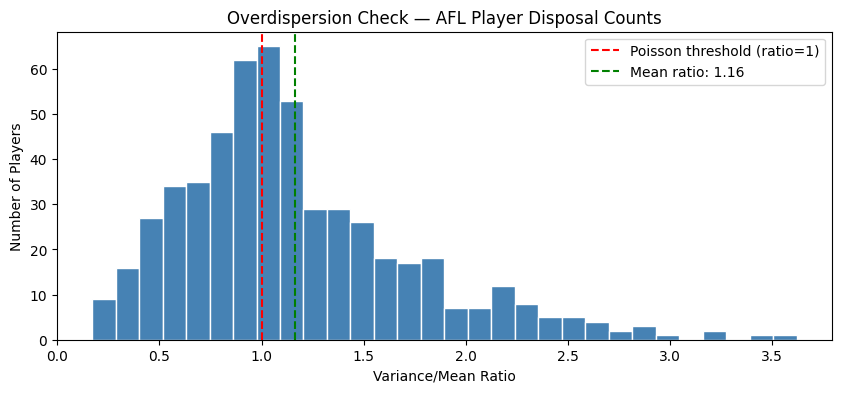

In [28]:
# test Poisson vs Negative Binomial fit across all players
from scipy import stats

overdispersion_ratios = []
for player, group in df_merged_clean.groupby('player'):
    if len(group) >= 5:
        mean = group['disposals'].mean()
        var = group['disposals'].var()
        if mean > 0:
            overdispersion_ratios.append(var / mean)

ratios = pd.Series(overdispersion_ratios)
print(f"Average variance/mean ratio across all players: {ratios.mean():.2f}")
print(f"% of players with ratio > 1.5 (overdispersed): {(ratios > 1.5).mean()*100:.1f}%")
print(f"% of players with ratio > 2.0 (strongly overdispersed): {(ratios > 2.0).mean()*100:.1f}%")

plt.figure(figsize=(10,4))
plt.hist(ratios, bins=30, color='steelblue', edgecolor='white')
plt.axvline(1.0, color='red', linestyle='--', label='Poisson threshold (ratio=1)')
plt.axvline(ratios.mean(), color='green', linestyle='--', label=f'Mean ratio: {ratios.mean():.2f}')
plt.xlabel('Variance/Mean Ratio')
plt.ylabel('Number of Players')
plt.title('Overdispersion Check — AFL Player Disposal Counts')
plt.legend()
plt.show()

In [29]:
from scipy import stats

def get_disposal_probs(player_name, predicted_mean, thresholds=[15, 20, 25, 30]):
    """Calculate probability of hitting disposal thresholds using best-fit distribution."""

    # get player's historical disposals
    player_data = df_merged_clean[df_merged_clean['player'] == player_name]['disposals'].dropna()

    if len(player_data) < 5:
        # fall back to Poisson for small samples
        dist = stats.poisson(predicted_mean)
        dist_name = 'Poisson'
        probs = {t: 1 - dist.cdf(t-1) for t in thresholds}
    else:
        mean = player_data.mean()
        var = player_data.var()
        ratio = var / mean if mean > 0 else 1.0

        if ratio > 1.5:
            # fit Negative Binomial
            # convert mean/var to n,p parameters
            p = mean / var
            n = mean * p / (1 - p)
            dist_name = f'Neg. Binomial (α={ratio:.2f})'
            probs = {t: 1 - stats.nbinom.cdf(t-1, n, p) for t in thresholds}
        else:
            # Poisson is fine
            dist = stats.poisson(predicted_mean)
            dist_name = 'Poisson'
            probs = {t: 1 - dist.cdf(t-1) for t in thresholds}

    return dist_name, probs

# test on a few players
test_players = [
    ('Daicos, Nick', 35.0),
    ('Oliver, Clayton', 32.0),
    ('Rachele, Josh', 20.0),
    ('Graham, Will', 12.0),
]

print(f"{'Player':<25} {'Model':<25} {'15+':>6} {'20+':>6} {'25+':>6} {'30+':>6}")
print("-" * 75)
for player, pred in test_players:
    dist_name, probs = get_disposal_probs(player, pred)
    print(f"{player:<25} {dist_name:<25} {probs[15]:>5.0%} {probs[20]:>5.0%} {probs[25]:>5.0%} {probs[30]:>5.0%}")

Player                    Model                        15+    20+    25+    30+
---------------------------------------------------------------------------
Daicos, Nick              Poisson                    100%  100%   97%   82%
Oliver, Clayton           Poisson                    100%   99%   91%   66%
Rachele, Josh             Neg. Binomial (α=1.81)      66%   32%   10%    2%
Graham, Will              Neg. Binomial (α=1.89)      24%    6%    1%    0%


In [30]:
from scipy import stats
import numpy as np

# ── STEP 1: Calculate per-player distribution parameters ──────────────────
player_dist_params = {}

for player, group in df_merged_clean.groupby('player'):
    disposals = group[group['disposals'] >= 5]['disposals'].dropna()
    if len(disposals) < 3:
        continue

    mean = disposals.mean()
    var = disposals.var()
    ratio = var / mean if mean > 0 else 1.0

    if ratio > 1.5:
        # Negative Binomial parameters
        p = mean / var
        n = mean * p / (1 - p)
        player_dist_params[player] = {
            'dist': 'nb',
            'ratio': round(ratio, 3),
            'n': round(n, 4),
            'p': round(p, 4),
        }
    else:
        # Poisson
        player_dist_params[player] = {
            'dist': 'poisson',
            'ratio': round(ratio, 3),
            'n': None,
            'p': None,
        }

print(f"Distribution params calculated for {len(player_dist_params)} players")
print(f"Using Poisson: {sum(1 for v in player_dist_params.values() if v['dist'] == 'poisson')}")
print(f"Using Neg. Binomial: {sum(1 for v in player_dist_params.values() if v['dist'] == 'nb')}")

# ── STEP 2: Function to get probabilities for a predicted mean ─────────────
def get_probs(player, predicted_mean, thresholds=[15, 20, 25, 30, 35]):
    params = player_dist_params.get(player)
    lam = max(predicted_mean, 0.1)

    if params is None or params['dist'] == 'poisson':
        dist = stats.poisson(lam)
    else:
        # scale NB params to use predicted mean not historical mean
        # keep overdispersion (ratio) but shift centre to predicted mean
        ratio = params['ratio']
        p = lam / (lam * ratio)
        n = lam * p / (1 - p)
        n = max(n, 0.1)
        p = min(max(p, 0.001), 0.999)
        dist = stats.nbinom(n, p)

    return {t: round(float(1 - dist.cdf(t - 1)), 3) for t in thresholds}

# ── STEP 3: Test on sample players ────────────────────────────────────────
test_cases = [
    ('Daicos, Nick', 35.0),
    ('Oliver, Clayton', 32.0),
    ('Neale, Lachie', 28.0),
    ('Rachele, Josh', 20.0),
    ('Graham, Will', 12.0),
    ('Worrell, Josh', 24.0),
]

print(f"\n{'Player':<25} {'Dist':<8} {'Ratio':>6} {'Pred':>6} {'15+':>6} {'20+':>6} {'25+':>6} {'30+':>6} {'35+':>6}")
print("-" * 85)
for player, pred in test_cases:
    params = player_dist_params.get(player, {})
    dist_name = params.get('dist', 'N/A')
    ratio = params.get('ratio', 0)
    probs = get_probs(player, pred)
    print(f"{player:<25} {dist_name:<8} {ratio:>6.2f} {pred:>6.1f} "
          f"{probs[15]:>5.0%} {probs[20]:>5.0%} {probs[25]:>5.0%} "
          f"{probs[30]:>5.0%} {probs[35]:>5.0%}")

# ── STEP 4: Add to JSON export ────────────────────────────────────────────
# convert to JSON-serializable format
player_dist_export = {}
for player, params in player_dist_params.items():
    player_dist_export[player] = {
        'dist': params['dist'],
        'ratio': params['ratio'],
        'n': params['n'],
        'p': params['p'],
    }

print(f"\nReady to export {len(player_dist_export)} player distributions")

Distribution params calculated for 569 players
Using Poisson: 448
Using Neg. Binomial: 121

Player                    Dist      Ratio   Pred    15+    20+    25+    30+    35+
-------------------------------------------------------------------------------------
Daicos, Nick              poisson    0.56   35.0  100%  100%   97%   82%   52%
Oliver, Clayton           poisson    0.70   32.0  100%   99%   91%   66%   32%
Neale, Lachie             poisson    1.15   28.0  100%   95%   74%   38%   11%
Rachele, Josh             nb         1.81   20.0   82%   50%   22%    7%    2%
Graham, Will              nb         1.89   12.0   28%    7%    1%    0%    0%
Worrell, Josh             poisson    0.67   24.0   98%   82%   45%   13%    2%

Ready to export 569 player distributions


## 15. Manual result checks (scratch — not required for the pipeline)

In [31]:
# actual disposals from tonight's game
actual_results = {
    # Sydney players
    'Heeney, Isaac':    {'disposals': 30, 'team': 'Sydney'},
    'Mills, Callum':    {'disposals': 32, 'team': 'Sydney'},
    'Warner, Chad':     {'disposals': 28, 'team': 'Sydney'},
    'Sheldrick, Angus': {'disposals': 28, 'team': 'Sydney'},
    'Bice, Riley':      {'disposals': 23, 'team': 'Sydney'},
    'Rowbottom, James': {'disposals': 23, 'team': 'Sydney'},
    'Blakey, Nick':     {'disposals': 19, 'team': 'Sydney'},
    'Gulden, Errol':    {'disposals': 18, 'team': 'Sydney'},
    'Wicks, Sam':       {'disposals': 17, 'team': 'Sydney'},
    'Grundy, Brodie':   {'disposals': 18, 'team': 'Sydney'},
    'Jordon, James':    {'disposals': 17, 'team': 'Sydney'},
    'Lloyd, Jake':      {'disposals': 14, 'team': 'Sydney'},
    'Serong, Jai':      {'disposals': 12, 'team': 'Sydney'},
    'Edwards, William': {'disposals': 14, 'team': 'Sydney'},
    'Curnow, Charlie':  {'disposals': 13, 'team': 'Sydney'},
    'McCartin, Tom':    {'disposals': 14, 'team': 'Sydney'},
    'Hamling, Joel':    {'disposals': 11,  'team': 'Sydney'},
    'Cunningham, Harry':{'disposals': 6,  'team': 'Sydney'},
    'Rosas, Malcolm':   {'disposals': 7,  'team': 'Sydney'},
    'McDonald, Logan':  {'disposals': 7,  'team': 'Sydney'},
    'Cleary, Caiden':   {'disposals': 7,  'team': 'Sydney'},
    'Ladhams, Peter':   {'disposals': 5,  'team': 'Sydney'},
    'Amartey, Joel':    {'disposals': 3,  'team': 'Sydney'},
    # Brisbane players
    'Dunkley, Josh':    {'disposals': 26, 'team': 'Brisbane Lions'},
    'Ashcroft, Will':   {'disposals': 30, 'team': 'Brisbane Lions'},
    'Neale, Lachie':    {'disposals': 27, 'team': 'Brisbane Lions'},
    'Fletcher, Jaspa':  {'disposals': 21, 'team': 'Brisbane Lions'},
    'Bailey, Zac':      {'disposals': 20, 'team': 'Brisbane Lions'},
    'Ashcroft, Levi':   {'disposals': 24, 'team': 'Brisbane Lions'},
    'Berry, Jarrod':    {'disposals': 18, 'team': 'Brisbane Lions'},
    'Wilmot, Darcy':    {'disposals': 16, 'team': 'Brisbane Lions'},
    'McKenna, Conor':   {'disposals': 15, 'team': 'Brisbane Lions'},
    'Gallop, Ty':       {'disposals': 14, 'team': 'Brisbane Lions'},
    'Andrews, Harris':  {'disposals': 12, 'team': 'Brisbane Lions'},
    'Fort, Darcy':      {'disposals': 15, 'team': 'Brisbane Lions'},
    'Cameron, Charlie': {'disposals': 12, 'team': 'Brisbane Lions'},
    'Answerth, Noah':   {'disposals': 14,  'team': 'Brisbane Lions'},
    'Gardiner, Darcy':  {'disposals': 12,  'team': 'Brisbane Lions'},
    'Rayner, Cam':      {'disposals': 13,  'team': 'Brisbane Lions'},
    'Tunstill, James':  {'disposals': 12,  'team': 'Brisbane Lions'},
    'Hipwood, Eric':    {'disposals': 7,  'team': 'Brisbane Lions'},
    'Draper, Sam':      {'disposals': 7,  'team': 'Brisbane Lions'},
    'Reville, Bruce':   {'disposals': 10,  'team': 'Brisbane Lions'},
    'Lester, Ryan':     {'disposals': 7,  'team': 'Brisbane Lions'},
    'Morris, Logan':    {'disposals': 8,  'team': 'Brisbane Lions'},
    'Lohmann, Kai':     {'disposals': 11,  'team': 'Brisbane Lions'},
}

# get venue edge for Gabba
venue = 'Gabba'
v_data = venue_edge_matrix[venue_edge_matrix['venue'] == venue].set_index('position')

OPP_WEIGHT = 0.916
VENUE_WEIGHT = 0.636

results = []
for player_name, info in actual_results.items():
    actual = info['disposals']
    team = info['team']
    opponent = 'Brisbane Lions' if team == 'Sydney' else 'Sydney'

    # get player base stats
    player_row = df_model[df_model['player'] == player_name]
    if player_row.empty:
        continue

    season_avg = float(player_row['disposals_per_game'].values[0])
    blended = float(player_row['blended_avg'].values[0])
    position = player_row['position'].values[0]

    # get opponent edge
    opp_edge_data = edge_matrix[
        (edge_matrix['opponent'] == opponent) &
        (edge_matrix['position'] == position)
    ]
    opp_edge = float(opp_edge_data['edge_score'].values[0]) if not opp_edge_data.empty else 0

    # get venue edge
    venue_edge = float(v_data.loc[position, 'edge_score']) if position in v_data.index else 0

    # combined prediction
    prediction = round(blended + (opp_edge * OPP_WEIGHT) + (venue_edge * VENUE_WEIGHT), 1)

    # floor = 20% below prediction
    floor = round(prediction * 0.80, 1)

    # success = above prediction OR within 20% below
    error = actual - prediction
    pct_below = (prediction - actual) / prediction if actual < prediction else 0
    success = actual >= prediction or pct_below <= 0.20

    results.append({
        'player': player_name,
        'team': team,
        'position': position,
        'season_avg': season_avg,
        'blended': blended,
        'prediction': prediction,
        'floor': floor,
        'actual': actual,
        'error': round(error, 1),
        'success': success
    })

results_df = pd.DataFrame(results)

# print results
print(f"Brisbane vs Sydney — Gabba — Round 17 2026")
print(f"{'='*75}")
print(f"{'Player':<25} {'Pos':<9} {'Blend':>6} {'Pred':>6} {'Floor':>6} {'Actual':>7} {'Error':>7} {'✓/✗':>5}")
print(f"{'-'*75}")

for _, row in results_df.sort_values('team').iterrows():
    flag = '✅' if row['success'] else '❌'
    print(f"{row['player']:<25} {row['position']:<9} {row['blended']:>6.1f} {row['prediction']:>6.1f} {row['floor']:>6.1f} {row['actual']:>7} {row['error']:>+7.1f} {flag:>5}")

print(f"\n{'='*75}")
total = len(results_df)
successes = results_df['success'].sum()
print(f"Total predictions: {total}")
print(f"Success (above pred OR within 20% below): {successes} / {total} ({successes/total*100:.1f}%)")
print(f"MAE: {results_df['error'].abs().mean():.2f} disposals")

# split by team
for team in ['Sydney', 'Brisbane Lions']:
    t = results_df[results_df['team'] == team]
    sr = t['success'].mean() * 100
    print(f"{team}: {t['success'].sum()}/{len(t)} ({sr:.1f}%)")

Brisbane vs Sydney — Gabba — Round 17 2026
Player                    Pos        Blend   Pred  Floor  Actual   Error   ✓/✗
---------------------------------------------------------------------------
Dunkley, Josh             MID-CON     22.5   23.4   18.7      26    +2.6     ✅
Neale, Lachie             MID-CON     31.0   31.9   25.5      27    -4.9     ✅
Fletcher, Jaspa           DEF-GEN     18.8   18.7   15.0      21    +2.3     ✅
Bailey, Zac               MID-ATK     21.0   22.0   17.6      20    -2.0     ✅
Ashcroft, Levi            MID-EXT     19.2   19.7   15.8      24    +4.3     ✅
Berry, Jarrod             WING        19.7   19.6   15.7      18    -1.6     ✅
Wilmot, Darcy             DEF-STO     22.4   20.7   16.6      16    -4.7     ❌
McKenna, Conor            FWD-GEN     12.2   12.7   10.2      15    +2.3     ✅
Gallop, Ty                FWD-KEY      9.3    8.8    7.0      14    +5.2     ✅
Andrews, Harris           DEF-KEY     15.2   13.9   11.1      12    -1.9     ✅
Fort, Darcy 

In [32]:
actual_results = {
    # GWS players
    'Oliver, Clayton':    {'disposals': 34, 'team': 'Greater Western Sydney'},
    'Callaghan, Finn':    {'disposals': 34, 'team': 'Greater Western Sydney'},
    'Whitfield, Lachie':  {'disposals': 33, 'team': 'Greater Western Sydney'},
    'Ash, Lachie':        {'disposals': 28, 'team': 'Greater Western Sydney'},
    'Greene, Toby':       {'disposals': 24, 'team': 'Greater Western Sydney'},
    'Fonti, Joe':         {'disposals': 21, 'team': 'Greater Western Sydney'},
    'Idun, Connor':       {'disposals': 19, 'team': 'Greater Western Sydney'},
    'Gothard, Phoenix':   {'disposals': 19, 'team': 'Greater Western Sydney'},
    'Himmelberg, Harry':  {'disposals': 18, 'team': 'Greater Western Sydney'},
    'Thomas, Harvey':     {'disposals': 17, 'team': 'Greater Western Sydney'},
    'Angwin, Ryan':       {'disposals': 15, 'team': 'Greater Western Sydney'},
    'Coniglio, Stephen':  {'disposals': 14, 'team': 'Greater Western Sydney'},
    'Taylor, Sam':        {'disposals': 14, 'team': 'Greater Western Sydney'},
    'Bedford, Toby':      {'disposals': 12, 'team': 'Greater Western Sydney'},
    'Stringer, Jake':     {'disposals': 11, 'team': 'Greater Western Sydney'},
    'Briggs, Kieren':     {'disposals': 11, 'team': 'Greater Western Sydney'},
    'Brown, Callum':      {'disposals': 11, 'team': 'Greater Western Sydney'},
    'Cadman, Aaron':      {'disposals': 10, 'team': 'Greater Western Sydney'},
    'Aleer, Leek':        {'disposals': 9,  'team': 'Greater Western Sydney'},
    'Stone, Conor':       {'disposals': 8,  'team': 'Greater Western Sydney'},
    'Oliver, Harrison':   {'disposals': 8,  'team': 'Greater Western Sydney'},
    'Gruzewski, Max':     {'disposals': 7,  'team': 'Greater Western Sydney'},
    'Daniels, Brent':     {'disposals': 4,  'team': 'Greater Western Sydney'},
    # Hawthorn players
    'Newcombe, Jai':      {'disposals': 31, 'team': 'Hawthorn'},
    'Day, Will':          {'disposals': 27, 'team': 'Hawthorn'},
    'Mackenzie, Cam':     {'disposals': 27, 'team': 'Hawthorn'},
    'Macdonald, Connor':  {'disposals': 25, 'team': 'Hawthorn'},
    'Battle, Josh':       {'disposals': 23, 'team': 'Hawthorn'},
    'Ginnivan, Jack':     {'disposals': 23, 'team': 'Hawthorn'},
    'Sicily, James':      {'disposals': 22, 'team': 'Hawthorn'},
    'Amon, Karl':         {'disposals': 21, 'team': 'Hawthorn'},
    'DAmbrosio, Massimo': {'disposals': 21, 'team': 'Hawthorn'},
    'Hardwick, Blake':    {'disposals': 20, 'team': 'Hawthorn'},
    'Morrison, Harry':    {'disposals': 16, 'team': 'Hawthorn'},
    'Ward, Josh':         {'disposals': 16, 'team': 'Hawthorn'},
    'Moore, Dylan':       {'disposals': 13, 'team': 'Hawthorn'},
    'Dalton, Jack':       {'disposals': 13, 'team': 'Hawthorn'},
    'Macdonald, Bailey':  {'disposals': 12, 'team': 'Hawthorn'},
    'Meek, Lloyd':        {'disposals': 11, 'team': 'Hawthorn'},
    'Chol, Mabior':       {'disposals': 9,  'team': 'Hawthorn'},
    'Lewis, Mitch':       {'disposals': 9,  'team': 'Hawthorn'},
    'Perez, Flynn':       {'disposals': 9,  'team': 'Hawthorn'},
    'Dear, Calsher':      {'disposals': 9,  'team': 'Hawthorn'},
    'Barrass, Tom':       {'disposals': 6,  'team': 'Hawthorn'},
    'Reeves, Ned':        {'disposals': 5,  'team': 'Hawthorn'},
    'Watson, Nick':       {'disposals': 5,  'team': 'Hawthorn'},
}

# venue is MCG
venue = 'M.C.G.'
v_data = venue_edge_matrix[venue_edge_matrix['venue'] == venue].set_index('position')

OPP_WEIGHT = 0.916
VENUE_WEIGHT = 0.636

results = []
for player_name, info in actual_results.items():
    actual = info['disposals']
    team = info['team']
    opponent = 'Hawthorn' if team == 'Greater Western Sydney' else 'Greater Western Sydney'

    player_row = df_model[df_model['player'] == player_name]
    if player_row.empty:
        continue

    season_avg = float(player_row['disposals_per_game'].values[0])
    blended = float(player_row['blended_avg'].values[0])
    position = player_row['position'].values[0]


    opp_edge_data = edge_matrix[
        (edge_matrix['opponent'] == opponent) &
        (edge_matrix['position'] == position)
    ]
    opp_edge = float(opp_edge_data['edge_score'].values[0]) if not opp_edge_data.empty else 0
    venue_edge = float(v_data.loc[position, 'edge_score']) if position in v_data.index else 0

    prediction = round(blended + (opp_edge * OPP_WEIGHT) + (venue_edge * VENUE_WEIGHT), 1)
    floor = round(prediction * 0.80, 1)
    error = actual - prediction
    pct_below = (prediction - actual) / prediction if actual < prediction else 0
    success = actual >= prediction or pct_below <= 0.20

    results.append({
        'player': player_name,
        'team': team,
        'position': position,
        'season_avg': season_avg,
        'blended': blended,
        'prediction': prediction,
        'floor': floor,
        'actual': actual,
        'error': round(error, 1),
        'success': success
    })

results_df = pd.DataFrame(results)
results_df = results_df[~results_df['player'].isin(['Daniels, Brent', 'Watson, Nick'])]

print(f"Hawthorn vs GWS — MCG — Round 17 2026")
print(f"{'='*75}")
print(f"{'Player':<25} {'Pos':<9} {'Blend':>6} {'Pred':>6} {'Floor':>6} {'Actual':>7} {'Error':>7} {'✓/✗':>5}")
print(f"{'-'*75}")

for _, row in results_df.sort_values('team').iterrows():
    flag = '✅' if row['success'] else '❌'
    print(f"{row['player']:<25} {row['position']:<9} {row['blended']:>6.1f} {row['prediction']:>6.1f} {row['floor']:>6.1f} {row['actual']:>7} {row['error']:>+7.1f} {flag:>5}")

print(f"\n{'='*75}")
total = len(results_df)
successes = results_df['success'].sum()
print(f"Total predictions: {total}")
print(f"Success: {successes} / {total} ({successes/total*100:.1f}%)")
print(f"MAE: {results_df['error'].abs().mean():.2f} disposals")

for team in ['Greater Western Sydney', 'Hawthorn']:
    t = results_df[results_df['team'] == team]
    sr = t['success'].mean() * 100
    print(f"{team}: {t['success'].sum()}/{len(t)} ({sr:.1f}%)")

Hawthorn vs GWS — MCG — Round 17 2026
Player                    Pos        Blend   Pred  Floor  Actual   Error   ✓/✗
---------------------------------------------------------------------------
Oliver, Clayton           MID-CON     33.8   32.1   25.7      34    +1.9     ✅
Oliver, Harrison          DEF-GEN     10.0    9.9    7.9       8    -1.9     ✅
Stone, Conor              WING        11.7   10.5    8.4       8    -2.5     ❌
Aleer, Leek               DEF-KEY      9.1    8.3    6.6       9    +0.7     ✅
Cadman, Aaron             FWD-KEY     10.6   10.7    8.6      10    -0.7     ✅
Brown, Callum             FWD-KEY     10.0   10.1    8.1      11    +0.9     ✅
Briggs, Kieren            RUC-TAP     12.9   12.1    9.7      11    -1.1     ✅
Stringer, Jake            FWD-GEN     12.6   12.3    9.8      11    -1.3     ✅
Bedford, Toby             MID-ATK     14.8   15.3   12.2      12    -3.3     ❌
Taylor, Sam               DEF-KEY     13.1   12.3    9.8      14    +1.7     ✅
Coniglio, Stephen

## 16. Interactive dashboard export (edge matrix + slip builder + Monte Carlo)

In [36]:
# @title
import pandas as pd
import json
import os
from io import StringIO

# ── REBUILD DEPENDENCIES ─────────────────────────────────────────────────
if 'round' not in df_merged_clean.columns:
    df_merged_clean = df_merged_clean.merge(
        df_games[['player','game_id','round']].drop_duplicates(),
        on=['player','game_id'],
        how='left'
    )

df_sorted = df_merged_clean[df_merged_clean['disposals'] >= 5].sort_values(['player','round'])

last5 = (df_sorted.groupby('player')
         .tail(5)
         .groupby('player')['disposals']
         .mean()
         .round(1)
         .rename('last5_avg'))

games_played = df_merged_clean.groupby('player')['game_id'].nunique().rename('games_played')

minor_venues = [
    'Norwood Oval', 'Barossa Park', 'Hands Oval', 'Traeger Park',
    'Marrara Oval', 'Bellerive Oval', 'York Park', 'Manuka Oval'
]
if 'venue_grouped' not in df_merged_clean.columns:
    df_merged_clean['venue_grouped'] = df_merged_clean['venue'].apply(
        lambda v: 'Interstate/Country Ground' if v in minor_venues else v
    )

game_totals = df_merged_clean.groupby('game_id')['disposals'].sum().rename('game_total_disposals')
team_games = df_merged_clean[['game_id','team']].drop_duplicates().merge(game_totals, on='game_id')
team_pace = team_games.groupby('team')['game_total_disposals'].mean().round(1).rename('avg_game_total')
league_avg = team_pace.mean()

pace_2026 = team_pace.reset_index()
pace_2026['pace_tier'] = pd.qcut(
    pace_2026['avg_game_total'], q=5,
    labels=['Very Slow', 'Slow', 'Medium', 'Fast', 'Very Fast']
)
pace_tier_lookup = dict(zip(pace_2026['team'], pace_2026['pace_tier']))

game_team_pairs = df_merged_clean[['game_id','team','opponent']].drop_duplicates()
game_team_pairs['team_tier'] = game_team_pairs['team'].map(pace_tier_lookup)
game_team_pairs['opp_tier'] = game_team_pairs['opponent'].map(pace_tier_lookup)
game_team_pairs['matchup_type'] = game_team_pairs.apply(
    lambda r: ' vs '.join(sorted([str(r['team_tier']), str(r['opp_tier'])])), axis=1
)
game_team_pairs = game_team_pairs.merge(game_totals, on='game_id')
game_team_pairs_unique = game_team_pairs.drop_duplicates(subset='game_id')

matchup_analysis = game_team_pairs_unique.groupby('matchup_type').agg(
    games=('game_id','count'),
    avg_total_disposals=('game_total_disposals','mean')
).round(1).reset_index()
matchup_analysis['pace_multiplier'] = (matchup_analysis['avg_total_disposals'] / league_avg).round(3)

venue_games = df_merged_clean[['game_id','venue_grouped']].drop_duplicates().merge(game_totals, on='game_id')
venue_pace = venue_games.groupby('venue_grouped').agg(
    games=('game_id','nunique'),
    avg_total_disposals=('game_total_disposals','mean')
).round(1).reset_index()
venue_pace['venue_pace_multiplier'] = (venue_pace['avg_total_disposals'] / league_avg).round(3)

print("All dependencies rebuilt")

# ── BUILD DATA STRUCTURES ───────────────────────────────────────────────
matrix_data = {}
for _, row in edge_matrix.iterrows():
    opp, pos = row['opponent'], row['position']
    if opp not in matrix_data: matrix_data[opp] = {}
    matrix_data[opp][pos] = {'edge': float(row['edge_score']), 'n': int(row['sample_size'])}

venue_data = {}
for _, row in venue_edge_matrix.iterrows():
    v, pos = row['venue'], row['position']
    if v not in venue_data: venue_data[v] = {}
    venue_data[v][pos] = {'edge': float(row['edge_score']), 'n': int(row['sample_size'])}

player_data = {}
for _, row in df_model.iterrows():
    team, pos = row['team'], row['position']
    if team not in player_data: player_data[team] = {}
    if pos not in player_data[team]: player_data[team][pos] = []
    player_data[team][pos].append({
        'name': row['player'],
        'avg': round(float(row['disposals_per_game']), 1),
        'last5': round(float(row['last5_avg']), 1) if pd.notna(row['last5_avg']) else round(float(row['disposals_per_game']), 1),
        'blended': round(float(row['blended_avg']), 1)
    })

for team in player_data:
    for pos in player_data[team]:
        player_data[team][pos].sort(key=lambda x: x['blended'], reverse=True)

venue_names = {
    'Adelaide Oval': 'Adelaide Oval',
    'Carrara': 'People First Stadium',
    'Docklands': 'Marvel Stadium',
    'Gabba': 'Gabba',
    'Interstate/Country Ground': 'Interstate/Country',
    'Kardinia Park': 'GMHBA Stadium',
    'M.C.G.': 'MCG',
    'Perth Stadium': 'Optus Stadium',
    'S.C.G.': 'SCG',
    'Sydney Showground': 'ENGIE Stadium',
}

player_avg_train = df_merged_clean.groupby('player')['disposals'].mean().round(1)

df_sorted_round = df_merged_clean.sort_values(['player', 'round'])

last10_clean = {}
for player, group in df_sorted_round.groupby('player'):
    games = group.tail(10)[['round', 'disposals', 'opponent']].to_dict('records')
    avg = float(round(group['disposals'].mean(), 1))
    threshold = round(avg * 0.80, 1)
    last10_clean[player] = {
        'avg': avg,
        'threshold': threshold,
        'games': [
            {
                'disposals': int(g['disposals']) if pd.notna(g['disposals']) else None,
                'opponent': g['opponent'],
                'fail': bool(g['disposals'] < threshold) if pd.notna(g['disposals']) else False
            }
            for g in games
        ]
    }

floor_tally_data = df_merged_clean.groupby(['player', 'team']).agg(
    games=('disposals', 'count'),
    below_10=('disposals', lambda x: (x < 10).sum()),
    avg=('disposals', 'mean'),
).reset_index()

floor_tally_data['avg'] = floor_tally_data['avg'].round(1)
floor_tally_data = floor_tally_data[
    (floor_tally_data['games'] >= 3) &
    (floor_tally_data['below_10'] > 0)
].sort_values('below_10', ascending=False)

floor_risk = {}
for _, row in floor_tally_data.iterrows():
    team = row['team']
    if team not in floor_risk:
        floor_risk[team] = []
    floor_risk[team].append({
        'player': row['player'],
        'below_10': int(row['below_10']),
        'games': int(row['games']),
        'avg': float(row['avg'])
    })

pace_export = {}
for team in pace_tier_lookup.keys():
    pace_export[team] = {
        'tier': str(pace_tier_lookup[team]),
        'avg_total': float(pace_2026[pace_2026['team'] == team]['avg_game_total'].values[0])
    }

pace_matchup_export = {}
for _, row in matchup_analysis.iterrows():
    pace_matchup_export[row['matchup_type']] = {
        'multiplier': float(row['pace_multiplier']),
        'games': int(row['games'])
    }

venue_pace_export = dict(zip(venue_pace['venue_grouped'], venue_pace['venue_pace_multiplier']))

# ── ASSEMBLE APP DATA ───────────────────────────────────────────────────
app_data = {
    'matrix': matrix_data,
    'venue': venue_data,
    'players': player_data,
    'last10': last10_clean,
    'floor_risk': floor_risk,
    'pace': pace_export,
    'pace_matchups': pace_matchup_export,
    'venue_pace': venue_pace_export,
    'distributions': player_dist_export,
    'weights': {'opp': 0.916, 'venue': 0.636},
    'teams': sorted(matrix_data.keys()),
    'venues': sorted(venue_data.keys()),
    'venue_names': venue_names
}

with open('afl_data.json', 'w') as f:
    json.dump(app_data, f)

print(f"Saved afl_data.json - Teams: {len(app_data['teams'])}, Venues: {len(app_data['venues'])}")

# ── HTML TEMPLATE (includes slip builder + Monte Carlo) ─────────────────
html_template = '''<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>AFL Disposal Edge Matrix</title>
<style>
#slip-panel.open { transform: translateX(0); }
#slip-panel { transform: translateX(100%); }
#slip-panel.open { transform: translateX(0); }
  * { box-sizing: border-box; margin: 0; padding: 0; }
  body { background: #0d1117; color: #e6edf3; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif; min-height: 100vh; }
  .header { padding: 24px 32px; border-bottom: 1px solid #21262d; }
  .header h1 { font-size: 20px; font-weight: 600; }
  .header p { font-size: 13px; color: #8b949e; margin-top: 4px; }
  .controls { display: flex; gap: 12px; padding: 20px 32px; background: #161b22; border-bottom: 1px solid #21262d; flex-wrap: wrap; align-items: center; }
  select { background: #21262d; color: #e6edf3; border: 1px solid #30363d; border-radius: 6px; padding: 8px 12px; font-size: 14px; cursor: pointer; min-width: 180px; }
  select:hover { border-color: #58a6ff; }
  .vs { color: #8b949e; font-size: 13px; font-weight: 500; }
  .matrix { padding: 24px 32px; }
  table { width: 100%; border-collapse: collapse; }
  th { padding: 10px 16px; text-align: center; font-size: 12px; font-weight: 600; color: #8b949e; text-transform: uppercase; letter-spacing: 0.5px; border-bottom: 1px solid #21262d; }
  th.pos-header { text-align: left; }
  th.team-header { font-size: 14px; color: #e6edf3; text-transform: none; letter-spacing: 0; }
  tr.pos-row { cursor: pointer; transition: background 0.15s; }
  tr.pos-row:hover { background: #161b22; }
  tr.pos-row.active { background: #1c2128; }
  td { padding: 10px 16px; border-bottom: 1px solid #21262d; }
  td.pos-label { font-size: 12px; font-weight: 600; color: #8b949e; white-space: nowrap; vertical-align: middle; }
  td.pos-label .chevron { font-size: 10px; transition: transform 0.2s; color: #484f58; display: inline-block; margin-right: 8px; }
  td.pos-label.open .chevron { transform: rotate(90deg); }
  td.score-cell { text-align: center; }
  .score-pill { display: inline-block; padding: 5px 14px; border-radius: 6px; font-weight: 700; font-size: 14px; min-width: 70px; text-align: center; }
  .score-n { font-size: 10px; font-weight: 400; opacity: 0.7; display: block; margin-top: 2px; }
  tr.expand-row td { padding: 0; border-bottom: none; }
  .expand-content { display: none; background: #1c2128; border-bottom: 1px solid #21262d; }
  .expand-content.open { display: block; }
  .expand-inner { display: grid; grid-template-columns: 1fr 1fr; gap: 0; }
  .team-players { padding: 16px 20px; }
  .team-players h4 { font-size: 12px; font-weight: 600; color: #8b949e; text-transform: uppercase; letter-spacing: 0.5px; margin-bottom: 12px; }
  .player-row { display: flex; justify-content: space-between; align-items: center; padding: 8px 0; border-bottom: 1px solid #21262d; }
  .player-row:last-child { border-bottom: none; }
  .player-name { font-size: 13px; color: #e6edf3; }
  .player-stats { display: flex; align-items: center; gap: 8px; font-size: 12px; }
  .stat-avg { color: #8b949e; }
  .stat-last5 { color: #58a6ff; font-weight: 600; }
  .stat-arrow { color: #484f58; }
  .stat-pred { color: #3fb950; font-weight: 600; }
  .divider { width: 1px; background: #21262d; }
  .legend { display: flex; gap: 16px; padding: 16px 32px; border-top: 1px solid #21262d; flex-wrap: wrap; }
  .leg { display: flex; align-items: center; gap: 6px; font-size: 12px; color: #8b949e; }
  .leg-dot { width: 12px; height: 12px; border-radius: 3px; }
  .footer { padding: 16px 32px; font-size: 11px; color: #484f58; border-top: 1px solid #21262d; }
  .stat-label { font-size: 10px; color: #484f58; display: block; text-align: right; margin-bottom: 6px; }
</style>
</head>
<body>

<div class="header">
  <h1>AFL Disposal Edge Matrix</h1>
  <p>Combined opponent + venue + pace edge scores — 2026 season</p>
</div>

<div class="controls">
  <select id="team1"></select>
  <span class="vs">vs</span>
  <select id="team2"></select>
  <select id="venue"></select>
</div>

<div class="matrix">
  <table id="matrix-table">
    <colgroup>
      <col style="width:160px;min-width:160px">
      <col>
      <col>
      <col>
    </colgroup>
    <thead>
      <tr>
        <th class="pos-header">Position</th>
        <th class="team-header" id="h-team1">—</th>
        <th class="team-header" id="h-team2">—</th>
        <th class="team-header" id="h-venue" style="opacity:0.6">Venue</th>
      </tr>
    </thead>
    <tbody id="matrix-body"></tbody>
  </table>
</div>

<div class="legend">
  <div class="leg"><div class="leg-dot" style="background:#0d4429"></div>Strong boost (≥+2)</div>
  <div class="leg"><div class="leg-dot" style="background:#132d1a"></div>Mild boost</div>
  <div class="leg"><div class="leg-dot" style="background:#21262d;border:1px solid #30363d"></div>Neutral</div>
  <div class="leg"><div class="leg-dot" style="background:#2d1f0a"></div>Mild suppress</div>
  <div class="leg"><div class="leg-dot" style="background:#3d0f0f"></div>Strong suppress</div>
  <div class="leg" style="margin-left:auto">
    <span style="color:#8b949e">Season avg</span>
    <span style="color:#484f58">|</span>
    <span style="color:#58a6ff">L5 avg</span>
    <span style="color:#484f58">→</span>
    <span style="color:#3fb950">Predicted</span>
  </div>
</div>

<div id="slip-panel" style="position:fixed;right:0;top:0;height:100vh;width:340px;background:#161b22;border-left:1px solid #21262d;padding:20px;overflow-y:auto;display:flex;flex-direction:column;gap:12px;z-index:50;transition:transform 0.25s ease;box-shadow:-4px 0 16px rgba(0,0,0,0.4)">
  <h3 style="font-size:14px;font-weight:600;color:#e6edf3">Slip builder</h3>
  <p id="slip-game-label" style="font-size:11px;color:#8b949e">No players added yet — click "+ Add to slip" under a player's probability chart.</p>
  <div id="slip-legs" style="display:flex;flex-direction:column;gap:8px"></div>
  <button id="run-mc-btn" onclick="runMonteCarlo()" style="display:none;margin-top:8px;padding:10px;background:#238636;color:#fff;border:none;border-radius:6px;font-weight:600;cursor:pointer">Run Monte Carlo</button>
  <div id="mc-results" style="margin-top:8px"></div>
</div>

<div id="slip-tab" onclick="toggleSlipPanel()" style="position:fixed;top:24px;right:0;background:#238636;color:#fff;padding:16px 20px;border-radius:10px 0 0 10px;cursor:pointer;font-size:16px;font-weight:700;z-index:51;box-shadow:-2px 0 8px rgba(0,0,0,0.3)">
  Slip <span id="slip-tab-count"></span>
</div>

<div class="footer">
  Combined edge = (opponent edge × 0.916 + venue edge × 0.636) × pace multiplier. Pace multiplier derived from 2026 season team/venue tempo tiers (5-tier, min. 5 games per matchup combination).
</div>

<script>
function toggleSlipPanel() {
  document.getElementById("slip-panel").classList.toggle("open");
}
const POSITIONS = [
  "DEF-GEN","DEF-KEY","DEF-STO","FWD-GEN","FWD-KEY","FWD-SML",
  "MID-ATK","MID-CON","MID-UNC","MID-EXT","MID-TAG",
  "RUC-HYB","RUC-MOB","RUC-TAP","WING"
];

function getColor(val) {
  if (val === null || val === undefined) return ["#21262d", "#8b949e"];
  if (val >= 2)   return ["#0d4429", "#3fb950"];
  if (val >= 1)   return ["#132d1a", "#56d364"];
  if (val >= 0.3) return ["#1a2d1a", "#7ee787"];
  if (val > -0.3) return ["#21262d", "#8b949e"];
  if (val > -1)   return ["#2d1f0a", "#d29922"];
  if (val > -2)   return ["#2d1515", "#f85149"];
  return ["#3d0f0f", "#ff7b72"];
}

function fmt(v) {
  if (v === null || v === undefined) return "—";
  return (v >= 0 ? "+" : "") + v.toFixed(1);
}

function getPaceMultiplier(t1, t2, venue) {
  const tier1 = DATA.pace[t1] ? DATA.pace[t1].tier : "Medium";
  const tier2 = DATA.pace[t2] ? DATA.pace[t2].tier : "Medium";
  const key = [tier1, tier2].sort().join(" vs ");
  const matchupData = DATA.pace_matchups[key];
  const teamMult = (matchupData && matchupData.games >= 5) ? matchupData.multiplier : 1.0;
  const venueMult = DATA.venue_pace[venue] || 1.0;
  return Math.round(((teamMult + venueMult) / 2) * 1000) / 1000;
}

function renderPaceBanner(t1, t2, venue) {
  const existing = document.getElementById("pace-banner");
  if (existing) existing.remove();

  const tier1 = DATA.pace[t1] ? DATA.pace[t1].tier : "Unknown";
  const tier2 = DATA.pace[t2] ? DATA.pace[t2].tier : "Unknown";
  const mult = getPaceMultiplier(t1, t2, venue);

  const tierColor = (tier) => {
    if (tier === "Very Fast") return "#3fb950";
    if (tier === "Fast") return "#7ee787";
    if (tier === "Medium") return "#8b949e";
    if (tier === "Slow") return "#d29922";
    return "#f85149";
  };

  const multColor = mult > 1.01 ? "#3fb950" : mult < 0.99 ? "#f85149" : "#8b949e";
  const multLabel = mult > 1.01 ? "Faster game expected" : mult < 0.99 ? "Slower game expected" : "Average pace expected";

  const banner = document.createElement("div");
  banner.id = "pace-banner";
  banner.style.cssText = "padding:14px 32px;background:#161b22;border-bottom:1px solid #21262d;display:flex;align-items:center;gap:24px;flex-wrap:wrap;";
  banner.innerHTML = `
    <div style="display:flex;align-items:center;gap:8px">
      <span style="font-size:12px;color:#8b949e">${t1}:</span>
      <span style="font-size:12px;font-weight:600;color:${tierColor(tier1)}">${tier1}</span>
    </div>
    <div style="display:flex;align-items:center;gap:8px">
      <span style="font-size:12px;color:#8b949e">${t2}:</span>
      <span style="font-size:12px;font-weight:600;color:${tierColor(tier2)}">${tier2}</span>
    </div>
    <div style="margin-left:auto;display:flex;align-items:center;gap:8px">
      <span style="font-size:12px;color:#8b949e">Pace multiplier:</span>
      <span style="font-size:13px;font-weight:700;color:${multColor}">×${mult.toFixed(3)}</span>
      <span style="font-size:11px;color:#484f58">(${multLabel})</span>
    </div>
  `;

  const controlsEl = document.querySelector(".controls");
  controlsEl.insertAdjacentElement("afterend", banner);
}

let DATA = null;
let slip = { t1: null, t2: null, venue: null, legs: [] };
let currentThresholds = {};

fetch("afl_data.json")
  .then(r => r.json())
  .then(data => { DATA = data; populateSelects(); render(); });

function populateSelects() {
  const s1 = document.getElementById("team1");
  const s2 = document.getElementById("team2");
  const sv = document.getElementById("venue");
  DATA.teams.forEach(t => {
    s1.innerHTML += `<option value="${t}">${t}</option>`;
    s2.innerHTML += `<option value="${t}">${t}</option>`;
  });
  s2.value = DATA.teams[1];
  DATA.venues.forEach(v => {
    sv.innerHTML += `<option value="${v}">${DATA.venue_names[v] || v}</option>`;
  });
  s1.addEventListener("change", render);
  s2.addEventListener("change", render);
  sv.addEventListener("change", render);
}

function makePlayerList(players, combined, team, position) {
  if (!players.length) return '<p style="color:#484f58;font-size:13px;padding:8px 0">No players</p>';
  const header = `<span class="stat-label">Season | L5 → Pred</span>`;
  const rows = players.map(p => {
    const pred = combined !== null ? (p.blended + combined).toFixed(1) : "—";
    const name = p.name.split(",").reverse().join(" ").trim();
    const last10data = DATA.last10[p.name];

    const formBoxes = last10data ? last10data.games.map(g => {
      if (g.disposals === null) return "";
      const bg = g.fail ? "#3d0f0f" : "#0d4429";
      const fg = g.fail ? "#ff7b72" : "#3fb950";
      const border = g.fail ? "#f85149" : "#238636";
      return `<span title="vs ${g.opponent}: ${g.disposals}"
        style="display:inline-block;width:26px;height:24px;background:${bg};color:${fg};
        border:1px solid ${border};border-radius:4px;font-size:11px;font-weight:600;
        text-align:center;line-height:24px;cursor:default">${g.disposals}</span>`;
    }).join("") : "";

return `<div class="player-row" style="flex-direction:row;align-items:center;gap:16px;padding:10px 0">
      <div style="flex:1;display:flex;flex-direction:column;gap:6px">
        <div style="display:flex;align-items:center;gap:8px">
          <span class="player-name">${name}</span>
          <span class="player-stats" style="margin-left:auto">
            <span class="stat-avg">${p.avg}</span>
            <span class="stat-arrow">|</span>
            <span class="stat-last5">${p.last5}</span>
            <span class="stat-arrow">→</span>
            <span class="stat-pred">${pred}</span>
          </span>
        </div>
        ${formBoxes ? `<div style="display:flex;gap:3px;flex-wrap:wrap;align-items:center">
          ${formBoxes}
          <span style="margin-left:6px;font-size:10px;color:#484f58">floor: ${last10data ? last10data.threshold : ''}</span>
        </div>` : ""}
      </div>
      <div style="width:220px;flex-shrink:0;border-left:1px solid #21262d;padding-left:16px">
        ${renderProbBars(p.name, combined !== null ? p.blended + combined : p.blended, team, position)}
      </div>
    </div>`;
  }).join("");
  return header + rows;
}

function render() {
  const t1 = document.getElementById("team1").value;
  const t2 = document.getElementById("team2").value;
  const venue = document.getElementById("venue").value;

  if (slip.legs.length > 0 && (slip.t1 !== t1 || slip.t2 !== t2 || slip.venue !== venue)) {
    slip = { t1: null, t2: null, venue: null, legs: [] };
    renderSlipPanel();
  }

  document.getElementById("h-team1").textContent = t1;
  document.getElementById("h-team2").textContent = t2;
  document.getElementById("h-venue").textContent = DATA.venue_names[venue] || venue;

  const t1_data = DATA.matrix[t2] || {};
  const t2_data = DATA.matrix[t1] || {};
  const v_data = DATA.venue[venue] || {};
  const W = DATA.weights;
  const paceMult = getPaceMultiplier(t1, t2, venue);
  const tbody = document.getElementById("matrix-body");
  tbody.innerHTML = "";

  POSITIONS.forEach(pos => {
    const opp1 = t1_data[pos] ? t1_data[pos].edge : null;
    const opp2 = t2_data[pos] ? t2_data[pos].edge : null;
    const ve = v_data[pos] ? v_data[pos].edge : 0;
    const vn = v_data[pos] ? v_data[pos].n : 0;
    if (opp1 === null && opp2 === null) return;

    const c1 = opp1 !== null ? Math.round((opp1 * W.opp + ve * W.venue) * paceMult * 10) / 10 : null;
    const c2 = opp2 !== null ? Math.round((opp2 * W.opp + ve * W.venue) * paceMult * 10) / 10 : null;
    const [bg1,fg1] = getColor(c1);
    const [bg2,fg2] = getColor(c2);
    const [bgv,fgv] = getColor(ve);
    const n1 = t1_data[pos] ? t1_data[pos].n : 0;
    const n2 = t2_data[pos] ? t2_data[pos].n : 0;

    const posRow = document.createElement("tr");
    posRow.className = "pos-row";
    posRow.innerHTML = `
      <td class="pos-label"><span class="chevron">▶</span>${pos}</td>
      <td class="score-cell"><span class="score-pill" style="background:${bg1};color:${fg1}">${fmt(c1)}<span class="score-n">n=${n1}</span></span></td>
      <td class="score-cell"><span class="score-pill" style="background:${bg2};color:${fg2}">${fmt(c2)}<span class="score-n">n=${n2}</span></span></td>
      <td class="score-cell"><span class="score-pill" style="background:${bgv};color:${fgv};opacity:0.8">${fmt(ve)}<span class="score-n">n=${vn}</span></span></td>
    `;

    const expandRow = document.createElement("tr");
    expandRow.className = "expand-row";
    const expandTd = document.createElement("td");
    expandTd.colSpan = 4;

    const t1Players = (DATA.players[t1] && DATA.players[t1][pos]) || [];
    const t2Players = (DATA.players[t2] && DATA.players[t2][pos]) || [];

expandTd.innerHTML = `
      <div class="expand-content" id="expand-${pos.replace("-","")}">
        <div style="display:grid;grid-template-columns:1fr 1fr;gap:0">
          <div class="team-players">
            <h4>${t1} — ${pos}</h4>
            ${makePlayerList(t1Players, c1, t1, pos)}
          </div>
          <div class="team-players" style="border-left:1px solid #21262d">
            <h4>${t2} — ${pos}</h4>
            ${makePlayerList(t2Players, c2, t2, pos)}
          </div>
        </div>
      </div>
    `;
    expandRow.appendChild(expandTd);

    posRow.addEventListener("click", () => {
      const expandEl = expandTd.querySelector(".expand-content");
      const labelEl = posRow.querySelector(".pos-label");
      const isOpen = expandEl.classList.contains("open");
      document.querySelectorAll(".expand-content.open").forEach(el => el.classList.remove("open"));
      document.querySelectorAll(".pos-row.active").forEach(el => el.classList.remove("active"));
      document.querySelectorAll(".pos-label.open").forEach(el => el.classList.remove("open"));
      if (!isOpen) {
        expandEl.classList.add("open");
        posRow.classList.add("active");
        labelEl.classList.add("open");
        setTimeout(initSliders, 50);
      }
    });

    tbody.appendChild(posRow);
    tbody.appendChild(expandRow);
  });

  renderFloorRisk(t1, t2);
  renderPaceBanner(t1, t2, venue);

}

function renderFloorRisk(t1, t2) {
  const existing = document.getElementById("floor-risk-section");
  if (existing) existing.remove();

  const t1Players = DATA.floor_risk[t1] || [];
  const t2Players = DATA.floor_risk[t2] || [];

  if (!t1Players.length && !t2Players.length) return;

  const makeRows = (players) => {
    if (!players.length) return `<p style="color:#484f58;font-size:13px;padding:8px 0">No risk players</p>`;
    return players.map(p => {
      const name = p.player.split(",").reverse().join(" ").trim();
      const rate = Math.round(p.below_10 / p.games * 100);
      const bg = p.below_10 >= 4 ? "#3d0f0f" : p.below_10 >= 2 ? "#2d1f0a" : "#1c2128";
      const fg = p.below_10 >= 4 ? "#ff7b72" : p.below_10 >= 2 ? "#d29922" : "#8b949e";
      return `<div style="display:flex;justify-content:space-between;align-items:center;
        padding:7px 12px;margin-bottom:4px;border-radius:6px;background:${bg}">
        <span style="font-size:13px;color:#e6edf3">${name}</span>
        <span style="font-size:12px;color:${fg};font-weight:600">
          ${p.below_10}x below 10
          <span style="font-weight:400;color:#484f58">(${rate}% of ${p.games} games · avg ${p.avg})</span>
        </span>
      </div>`;
    }).join("");
  };

  const section = document.createElement("div");
  section.id = "floor-risk-section";
  section.style.cssText = "padding:24px 32px;border-top:1px solid #21262d;";
  section.innerHTML = `
    <h3 style="font-size:14px;font-weight:600;color:#e6edf3;margin-bottom:4px">
      ⚠️ Risk Players
    </h3>
    <p style="font-size:12px;color:#8b949e;margin-bottom:16px">
      Players who have scored below 10 disposals at least once this season
    </p>
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:24px">
      <div>
        <h4 style="font-size:12px;font-weight:600;color:#8b949e;text-transform:uppercase;
          letter-spacing:0.5px;margin-bottom:10px">${t1}</h4>
        ${makeRows(t1Players)}
      </div>
      <div>
        <h4 style="font-size:12px;font-weight:600;color:#8b949e;text-transform:uppercase;
          letter-spacing:0.5px;margin-bottom:10px">${t2}</h4>
        ${makeRows(t2Players)}
      </div>
    </div>
  `;

  document.body.appendChild(section);
}

function getProbs(playerName, predictedMean, thresholds) {
  const params = DATA.distributions[playerName];
  if (!params) return null;

  const lam = Math.max(predictedMean, 0.1);
  const probs = {};

  thresholds.forEach(t => {
    if (params.dist === 'poisson') {
      probs[t] = 1 - poissonCDF(lam, t - 1);
    } else {
      const ratio = params.ratio;
      let p = lam / (lam * ratio);
      let n = lam * p / (1 - p);
      n = Math.max(n, 0.1);
      p = Math.min(Math.max(p, 0.001), 0.999);
      probs[t] = 1 - nbinomCDF(n, p, t - 1);
    }
  });
  return probs;
}

function poissonCDF(lambda, k) {
  let sum = 0;
  let term = Math.exp(-lambda);
  for (let i = 0; i <= k; i++) {
    sum += term;
    term *= lambda / (i + 1);
  }
  return Math.min(sum, 1);
}

function nbinomCDF(n, p, k) {
  let sum = 0;
  for (let i = 0; i <= k; i++) {
    sum += nbinomPMF(n, p, i);
  }
  return Math.min(sum, 1);
}

function nbinomPMF(n, p, k) {
  const logC = logGamma(n + k) - logGamma(k + 1) - logGamma(n);
  return Math.exp(logC + n * Math.log(p) + k * Math.log(1 - p));
}

function logGamma(z) {
  const c = [76.18009172947146, -86.50532032941677, 24.01409824083091,
              -1.231739572450155, 0.1208650973866179e-2, -0.5395239384953e-5];
  let x = z, y = z, tmp = x + 5.5;
  tmp -= (x + 0.5) * Math.log(tmp);
  let ser = 1.000000000190015;
  for (let j = 0; j < 6; j++) ser += c[j] / ++y;
  return -tmp + Math.log(2.5066282746310005 * ser / x);
}

function renderProbBars(playerName, predictedMean, team, position) {
  const params = DATA.distributions[playerName];
  if (!params) return '';

  const uniqueId = playerName.replace(/[^a-zA-Z0-9]/g, '_');
  const distLabel = params.dist === 'nb' ? `NB α=${params.ratio}` : `Poisson`;

  return `<div style="padding:6px 0">
    <canvas id="curve_${uniqueId}" width="340" height="80"
      style="width:100%;height:80px;cursor:crosshair;display:block"
      onmousedown="startDrag('${uniqueId}','${playerName}',${predictedMean},event)"
      onmousemove="onDrag('${uniqueId}','${playerName}',${predictedMean},event)"
      onmouseup="stopDrag()"
      onmouseleave="stopDrag()">
    </canvas>
    <div style="display:flex;justify-content:space-between;align-items:center;margin-top:2px">
      <span style="font-size:10px;color:#484f58">${distLabel}</span>
      <span id="prob_${uniqueId}" style="font-size:16px;font-weight:700;color:#3fb950">—</span>
    </div>
    <button onclick="addToSlip('${uniqueId}','${playerName}','${team}','${position}')"
      style="margin-top:6px;width:100%;padding:6px;background:#21262d;color:#e6edf3;border:1px solid #30363d;border-radius:6px;font-size:11px;cursor:pointer">
      + Add to slip
    </button>
  </div>`;
}

function updateProb(uid, playerName, predictedMean, threshold) {
  threshold = parseInt(threshold);
  const probs = getProbs(playerName, predictedMean, [threshold]);
  if (!probs) return;

  const pct = Math.round(probs[threshold] * 100);
  const color = pct >= 70 ? '#3fb950' : pct >= 40 ? '#d29922' : '#f85149';

  document.getElementById(`thresh_${uid}`).textContent = `${threshold}+`;
  document.getElementById(`prob_${uid}`).textContent = `${pct}%`;
  document.getElementById(`prob_${uid}`).style.color = color;
  document.getElementById(`bar_${uid}`).style.width = `${pct}%`;
  document.getElementById(`bar_${uid}`).style.background = color;
}

let isDragging = false;

function startDrag(uid, playerName, predictedMean, e) {
  isDragging = true;
  onDrag(uid, playerName, predictedMean, e);
}

function stopDrag() {
  isDragging = false;
}

function onDrag(uid, playerName, predictedMean, e) {
  if (e.type === 'mousemove' && !isDragging) return;
  const canvas = document.getElementById(`curve_${uid}`);
  if (!canvas) return;
  const rect = canvas.getBoundingClientRect();
  const xFrac = Math.max(0, Math.min(1, (e.clientX - rect.left) / rect.width));
  drawCurve(uid, playerName, predictedMean, xFrac);
}

function drawCurve(uid, playerName, predictedMean, xFrac) {
  const canvas = document.getElementById(`curve_${uid}`);
  if (!canvas) return;
  const ctx = canvas.getContext('2d');
  const W = canvas.width;
  const H = canvas.height;

  const params = DATA.distributions[playerName];
  const lam = Math.max(predictedMean, 0.1);

  const stdDev = params && params.dist === 'nb'
    ? Math.sqrt(lam * params.ratio)
    : Math.sqrt(lam);
  const xMin = Math.max(0, Math.floor(lam - 3.5 * stdDev));
  const xMax = Math.ceil(lam + 3.5 * stdDev);
  const range = xMax - xMin;

  const pmfValues = [];
  let maxPmf = 0;
  for (let x = xMin; x <= xMax; x++) {
    let pmf;
    if (params && params.dist === 'nb') {
      const ratio = params.ratio;
      let p = lam / (lam * ratio);
      let n = lam * p / (1 - p);
      n = Math.max(n, 0.1);
      p = Math.min(Math.max(p, 0.001), 0.999);
      pmf = nbinomPMF(n, p, x);
    } else {
      pmf = Math.exp(-lam) * Math.pow(lam, x) / Math.exp(logGamma(x + 1));
    }
    pmfValues.push({ x, pmf });
    if (pmf > maxPmf) maxPmf = pmf;
  }

  const threshold = Math.round(xMin + xFrac * range);
  currentThresholds[uid] = threshold;

  ctx.clearRect(0, 0, W, H);

  const barW = W / pmfValues.length;
  pmfValues.forEach((d, i) => {
    const barH = (d.pmf / maxPmf) * (H - 10);
    const bx = i * barW;
    const by = H - barH;
    ctx.fillStyle = d.x >= threshold ? '#1f6feb' : '#0d4429';
    ctx.fillRect(bx + 1, by, barW - 2, barH);
  });

  const lineX = ((threshold - xMin) / range) * W;
  ctx.strokeStyle = '#58a6ff';
  ctx.lineWidth = 2;
  ctx.setLineDash([4, 3]);
  ctx.beginPath();
  ctx.moveTo(lineX, 0);
  ctx.lineTo(lineX, H);
  ctx.stroke();
  ctx.setLineDash([]);

  ctx.fillStyle = '#58a6ff';
  ctx.font = 'bold 11px sans-serif';
  ctx.textAlign = lineX > W / 2 ? 'right' : 'left';
  ctx.fillText(`${threshold}+`, lineX + (lineX > W / 2 ? -6 : 6), 14);

  const thresholds = [threshold];
  const probs = getProbs(playerName, predictedMean, thresholds);
  if (!probs) return;
  const pct = Math.round(probs[threshold] * 100);
  const color = pct >= 70 ? '#3fb950' : pct >= 40 ? '#d29922' : '#f85149';

  const probEl = document.getElementById(`prob_${uid}`);
  if (probEl) {
    probEl.textContent = `P(≥${threshold}) = ${pct}%`;
    probEl.style.color = color;
  }
}

function initSliders() {
  document.querySelectorAll('canvas[id^="curve_"]').forEach(canvas => {
    const uid = canvas.id.replace('curve_', '');
    const attr = canvas.getAttribute('onmousedown');
    const match = attr.match(/'([^']+)','([^']+)',([\d.]+)/);
    if (match) {
      const playerName = match[2];
      const predictedMean = parseFloat(match[3]);
      const params = DATA.distributions[playerName];
      const lam = Math.max(predictedMean, 0.1);
      const stdDev = params && params.dist === 'nb'
        ? Math.sqrt(lam * params.ratio) : Math.sqrt(lam);
      const xMin = Math.max(0, Math.floor(lam - 3.5 * stdDev));
      const xMax = Math.ceil(lam + 3.5 * stdDev);
      const range = xMax - xMin;
      const xFrac = (lam - xMin) / range;
      drawCurve(uid, playerName, predictedMean, xFrac);
    }
  });
}

function getEdgeComponents(team, opponent, position, venue) {
  const oppData = DATA.matrix[opponent] ? DATA.matrix[opponent][position] : null;
  const vData = DATA.venue[venue] ? DATA.venue[venue][position] : null;
  return {
    opp_edge: oppData ? oppData.edge : 0,
    venue_edge: vData ? vData.edge : 0
  };
}

function addToSlip(uid, playerName, team, position) {
  const t1 = document.getElementById("team1").value;
  const t2 = document.getElementById("team2").value;
  const venue = document.getElementById("venue").value;

  if (slip.legs.some(l => l.playerName === playerName)) {
    alert(`${playerName} is already on the slip.`);
    return;
  }
  if (slip.legs.length === 0) { slip.t1 = t1; slip.t2 = t2; slip.venue = venue; }

  const opponent = team === t1 ? t2 : t1;
  const edges = getEdgeComponents(team, opponent, position, venue);
  const playerObj = ((DATA.players[team] && DATA.players[team][position]) || []).find(p => p.name === playerName);
  if (!playerObj) return;

  const threshold = currentThresholds[uid] || Math.round(playerObj.blended);

  slip.legs.push({
    uid, playerName, team, opponent, position,
    blended: playerObj.blended,
    opp_edge: edges.opp_edge,
    venue_edge: edges.venue_edge,
    threshold
  });
document.getElementById("slip-panel").classList.add("open");
  renderSlipPanel();
}

function removeFromSlip(i) {
  slip.legs.splice(i, 1);
  if (slip.legs.length === 0) { slip.t1 = null; slip.t2 = null; slip.venue = null; }
  renderSlipPanel();
}

function renderSlipPanel() {
  const legsEl = document.getElementById("slip-legs");
  const labelEl = document.getElementById("slip-game-label");
  const btnEl = document.getElementById("run-mc-btn");
  const resultsEl = document.getElementById("mc-results");
  const tabCount = document.getElementById("slip-tab-count");
  tabCount.textContent = slip.legs.length > 0 ? `(${slip.legs.length})` : "";

  if (slip.legs.length === 0) {
    labelEl.textContent = "No players added yet — click '+ Add to slip' under a player's probability chart.";
    legsEl.innerHTML = "";
    btnEl.style.display = "none";
    resultsEl.innerHTML = "";
    return;
  }

  labelEl.textContent = `${slip.t1} vs ${slip.t2} — ${DATA.venue_names[slip.venue] || slip.venue}`;
  legsEl.innerHTML = slip.legs.map((l, i) => {
    const name = l.playerName.split(",").reverse().join(" ").trim();
    return `<div style="display:flex;justify-content:space-between;align-items:center;background:#21262d;border-radius:6px;padding:8px 10px;font-size:12px">
      <span>${name} <span style="color:#8b949e">${l.threshold}+</span></span>
      <span onclick="removeFromSlip(${i})" style="cursor:pointer;color:#f85149;font-weight:700">×</span>
    </div>`;
  }).join("");
  btnEl.style.display = "block";
  resultsEl.innerHTML = "";
}

function randomNormal(mean, sd) {
  let u = 0, v = 0;
  while (u === 0) u = Math.random();
  while (v === 0) v = Math.random();
  return mean + sd * Math.sqrt(-2 * Math.log(u)) * Math.cos(2 * Math.PI * v);
}

function sampleFromDist(playerName, predictedMean) {
  const params = DATA.distributions[playerName];
  const lam = Math.max(predictedMean, 0.1);
  const u = Math.random();
  let k = 0, cum;
  if (!params || params.dist === 'poisson') {
    let term = Math.exp(-lam);
    cum = term;
    while (cum < u && k < 200) { k++; term *= lam / k; cum += term; }
  } else {
    const ratio = params.ratio;
    let p = lam / (lam * ratio);
    let n = lam * p / (1 - p);
    n = Math.max(n, 0.1);
    p = Math.min(Math.max(p, 0.001), 0.999);
    cum = nbinomPMF(n, p, 0);
    while (cum < u && k < 200) { k++; cum += nbinomPMF(n, p, k); }
  }
  return k;
}

function runMonteCarlo(nIter = 10000) {
  const resultsEl = document.getElementById("mc-results");
  resultsEl.innerHTML = `<p style="font-size:12px;color:#8b949e">Simulating ${nIter.toLocaleString()} iterations...</p>`;

  setTimeout(() => {
    const W = DATA.weights;
    const centralMult = getPaceMultiplier(slip.t1, slip.t2, slip.venue);
    const paceSD = 0.08;

    let allHit = 0;
    const legHits = new Array(slip.legs.length).fill(0);
    const legIndependentP = slip.legs.map(l => {
      const meanFixed = l.blended + (l.opp_edge * W.opp + l.venue_edge * W.venue) * centralMult;
      const probs = getProbs(l.playerName, meanFixed, [l.threshold]);
      return probs ? probs[l.threshold] : null;
    });

    for (let iter = 0; iter < nIter; iter++) {
      const paceDraw = centralMult * Math.exp(randomNormal(0, paceSD));
      let sliphit = true;
      slip.legs.forEach((l, i) => {
        const predMean = l.blended + (l.opp_edge * W.opp + l.venue_edge * W.venue) * paceDraw;
        const sample = sampleFromDist(l.playerName, predMean);
        const hit = sample >= l.threshold;
        if (hit) legHits[i]++;
        if (!hit) sliphit = false;
      });
      if (sliphit) allHit++;
    }

    const combinedRate = (allHit / nIter * 100).toFixed(1);
    const independentProduct = legIndependentP.every(p => p !== null)
      ? (legIndependentP.reduce((a, b) => a * b, 1) * 100).toFixed(1)
      : null;

    let html = `<div style="border-top:1px solid #21262d;padding-top:12px;margin-top:4px">
      <p style="font-size:11px;color:#8b949e;margin-bottom:6px">Per-leg simulated hit rate</p>`;
    slip.legs.forEach((l, i) => {
      const name = l.playerName.split(",").reverse().join(" ").trim();
      const rate = (legHits[i] / nIter * 100).toFixed(1);
      html += `<div style="display:flex;justify-content:space-between;font-size:12px;padding:3px 0">
        <span>${name} ${l.threshold}+</span><span style="color:#7ee787">${rate}%</span></div>`;
    });
    html += `<div style="margin-top:10px;padding-top:10px;border-top:1px solid #30363d">
      <div style="display:flex;justify-content:space-between;font-size:13px;font-weight:700">
        <span>Full slip hits (Monte Carlo)</span><span style="color:#3fb950">${combinedRate}%</span>
      </div>`;
    if (independentProduct !== null) {
      html += `<div style="display:flex;justify-content:space-between;font-size:11px;color:#8b949e;margin-top:4px">
        <span>If independent (naive product)</span><span>${independentProduct}%</span>
      </div>`;
    }
    html += `</div></div>`;
    resultsEl.innerHTML = html;
  }, 30);
}
</script>
</body>
</html>
'''

with open('afl_edge_matrix.html', 'w') as f:
    f.write(html_template)

with open('afl_data.json', 'r') as f:
    data_str = f.read()

with open('afl_edge_matrix.html', 'r') as f:
    html = f.read()

fetch_block = '''fetch("afl_data.json")
  .then(r => r.json())
  .then(data => { DATA = data; populateSelects(); render(); });'''

inline_block = f'DATA = {data_str};\npopulateSelects();\nrender();'

html = html.replace(fetch_block, inline_block)

with open('afl_edge_matrix_standalone.html', 'w') as f:
    f.write(html)

print("Done! Download afl_edge_matrix_standalone.html")


<>:811: SyntaxWarning: invalid escape sequence '\d'
<>:811: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_393/1185114712.py:811: SyntaxWarning: invalid escape sequence '\d'
  const match = attr.match(/'([^']+)','([^']+)',([\d.]+)/);


All dependencies rebuilt
Saved afl_data.json - Teams: 18, Venues: 10
Done! Download afl_edge_matrix_standalone.html
